# Ultrasound Model Comparison: Trained Models vs Baselines

This notebook compares:

- **Three trained EchoCare-CLIP models** saved from `experiment_training_Mar26.ipynb`
- **OpenAI CLIP** zero-shot baseline
- **BiomedCLIP** zero-shot baseline

using two evaluations on a **held-out test split** of the labeled ultrasound datasets:

1. **Alignment score**: mean cosine similarity of matched image-caption pairs  
2. **Classification accuracy**: classify each image into a label using **prompted label text** and image-text similarity

This notebook is intentionally focused on **BUSI** and **BrEaST** because those datasets have label columns in the CSVs, making classification evaluation meaningful.


## Notebook roadmap

This notebook is organized into four blocks:

1. **Setup and dataset reconstruction**  
   Load dependencies, recreate the train/val/test split, and build evaluation datasets.

2. **Model loading and zero-shot evaluation**  
   Load OpenAI CLIP, BiomedCLIP, and trained models. Evaluate paired alignment and prompt-based zero-shot classification.

3. **Held-out supervised evaluation**  
   Extract frozen embeddings, run per-organ linear probes, and compare against few-shot adaptation on the held-out test split.

4. **Extra diagnostic tests**  
   Add retrieval metrics, bootstrap confidence intervals, and confusion-matrix diagnostics for the best probe results.

This version assumes the same Kaggle file layout and input format used earlier in the notebook.

In [ ]:
# Install dependencies (run once)
!pip install -q monai transformers open_clip_torch einops pandas pillow matplotlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
import os
import hashlib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from transformers import (
    CLIPModel,
    CLIPProcessor,
    CLIPTextModel,
    CLIPTokenizer,
)
from monai.networks.nets.swin_unetr import SwinTransformer

from open_clip import create_model_from_pretrained, get_tokenizer

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

import os

base_dir = "/content/gdrive/MyDrive"

liver_dir = "/content/gdrive/MyDrive/Liver_ultrasound"
print(os.listdir(base_dir)[:20])
print(os.listdir(liver_dir)[:20])

Mounted at /content/gdrive
['无标题文档 (1).gdoc', 'virus-explorer-worksheet copy.pdf', 'virus-explorer-worksheet copy (1).gdoc', 'virus-explorer-worksheet copy.gdoc', '报告 (2).gdoc', '报告 (1).gdoc', '无标题文档.gdoc', 'take me w you edit', 'Ruirui Lan Res2.pdf', '报告.gdoc', 'Report (5).gdoc', 'analyze', 'Untitled document (23).gdoc', 'musicology 12W first paper.gdoc', 'Report (4).gdoc', 'report 2.gdoc', 'report 3.gdoc', 'musicology 12W second paper.gdoc', 'Untitled document (22).gdoc', 'To-do list.gsheet']
['captions.csv', '.DS_Store', 'AULI_resized_images']


In [ ]:
config = {
    # ------------------------------------------------------------------
    # Liver holdout test set (no split reconstruction)
    # ------------------------------------------------------------------
    "liver_csv":        "/content/gdrive/MyDrive/Liver_ultrasound/captions.csv",
    "liver_image_root": "/content/gdrive/MyDrive/Liver_ultrasound/AULI_resized_images",
    "organ":            "liver",

    # ------------------------------------------------------------------
    # Saved models
    # ------------------------------------------------------------------
    # "saved_model_dir": "/content/gdrive/MyDrive/BMI702 Project/checkpoints_llm",
    "saved_model_dir": "/content/gdrive/MyDrive/Saved_Models",
    "trained_models": {
        "MLP heads only":      "echocare_clip_mlp_heads_only.pt",
        "MLP + image encoder": "echocare_clip_mlp_and_image_encoder.pt",
        "MLP + text encoder":  "echocare_clip_mlp_and_text_encoder.pt",
    },

    # ------------------------------------------------------------------
    # Model settings (must match training notebook — do not change)
    # ------------------------------------------------------------------
    "feature_size": 128,
    "in_channels": 3,
    "image_size": 256,
    "projection_dim": 256,
    "clip_model_name": "openai/clip-vit-base-patch32",
    "max_seq_len": 77,
    "img_mean": [0.190874, 0.192657, 0.196386],
    "img_std":  [0.200044, 0.201410, 0.204307],

    # ------------------------------------------------------------------
    # Baseline model names
    # ------------------------------------------------------------------
    "openai_clip_model_name": "openai/clip-vit-base-patch32",
    "biomedclip_model_name":  "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",

    # ------------------------------------------------------------------
    # Evaluation settings
    # ------------------------------------------------------------------
    "random_seed": 42,
    "batch_size": 32,
    "num_workers": 2,
    "results_dir": "/content/gdrive/MyDrive/liver_zeroshot_results",
}
config

{'liver_csv': '/content/gdrive/MyDrive/Liver_ultrasound/captions.csv',
 'liver_image_root': '/content/gdrive/MyDrive/Liver_ultrasound/AULI_resized_images',
 'organ': 'liver',
 'saved_model_dir': '/content/gdrive/MyDrive/Saved_Models',
 'trained_models': {'MLP heads only': 'echocare_clip_mlp_heads_only.pt',
  'MLP + image encoder': 'echocare_clip_mlp_and_image_encoder.pt',
  'MLP + text encoder': 'echocare_clip_mlp_and_text_encoder.pt'},
 'feature_size': 128,
 'in_channels': 3,
 'image_size': 256,
 'projection_dim': 256,
 'clip_model_name': 'openai/clip-vit-base-patch32',
 'max_seq_len': 77,
 'img_mean': [0.190874, 0.192657, 0.196386],
 'img_std': [0.200044, 0.20141, 0.204307],
 'openai_clip_model_name': 'openai/clip-vit-base-patch32',
 'biomedclip_model_name': 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224',
 'random_seed': 42,
 'batch_size': 32,
 'num_workers': 2,
 'results_dir': '/content/gdrive/MyDrive/liver_zeroshot_results'}

In [ ]:
# ============================================================
# Liver holdout: load CSV directly (no split reconstruction)
# ============================================================
import os
import pandas as pd

# --- 1. Read raw CSV ---
raw = pd.read_csv(config["liver_csv"])
print(f"Loaded {len(raw):,} rows from {config['liver_csv']}")
print(f"Columns: {list(raw.columns)}")
print(raw.head(3))

# --- 2. Standardize to (image_path, caption, label, dataset) ---
# CSV has: file_name, caption, Label, caption_type
liver_df = pd.DataFrame({
    "image_path": raw["file_name"].astype(str),
    "caption":    raw["caption"].astype(str),
    "label":      raw["Label"].astype(str).str.strip().str.lower(),
    "dataset":    "liver_holdout",
})

# --- 3. Resolve image paths against liver_image_root ---
def resolve_liver_path(fname, root):
    p = os.path.join(root, str(fname))
    return os.path.abspath(p) if os.path.exists(p) else None

liver_df["image_path"] = liver_df["image_path"].apply(
    lambda f: resolve_liver_path(f, config["liver_image_root"])
)

# --- 4. Drop missing-image rows ---
n_total   = len(liver_df)
n_missing = liver_df["image_path"].isna().sum()
liver_df  = liver_df.dropna(subset=["image_path"]).reset_index(drop=True)

print(f"\nResolved {n_total - n_missing}/{n_total} images "
      f"({n_missing} missing)")
if n_missing > 0:
    print(f"  WARNING: {n_missing} rows dropped due to missing image files.")
    print(f"  Verify config['liver_image_root']: {config['liver_image_root']}")

# --- 5. Sanity reports ---
print(f"\nFinal dataset: {len(liver_df):,} samples")
print(f"\nLabel distribution:")
print(liver_df["label"].value_counts())
print(f"\nFirst 3 rows:")
print(liver_df.head(3))

# --- 6. Expose under names downstream cells expect ---
# Original notebook constructs `full_df` here, then splits to test_df / labeled_test_df.
# We bypass splitting: liver IS the holdout, so labeled_test_df = liver_df directly.
full_df          = liver_df.copy()    # for any downstream cells that still reference full_df
test_df          = liver_df.copy()    # used by alignment cells (cells 19-21)
labeled_test_df  = liver_df.copy()    # used by classification cells (cells 23-28)

Loaded 735 rows from /content/gdrive/MyDrive/Liver_ultrasound/captions.csv
Columns: ['file_name', 'caption', 'Label', 'caption_type']
              file_name                                            caption  \
0    liver_benign_1.png  A B-mode ultrasound of liver, consistent with ...   
1   liver_benign_10.png  An ultrasound image of liver with benign findi...   
2  liver_benign_100.png  A clinical ultrasound scan of liver, indicativ...   

    Label      caption_type  
0  benign  tissue+condition  
1  benign  tissue+condition  
2  benign  tissue+condition  

Resolved 735/735 images (0 missing)

Final dataset: 735 samples

Label distribution:
label
malignant    435
benign       200
normal       100
Name: count, dtype: int64

First 3 rows:
                                          image_path  \
0  /content/gdrive/MyDrive/Liver_ultrasound/AULI_...   
1  /content/gdrive/MyDrive/Liver_ultrasound/AULI_...   
2  /content/gdrive/MyDrive/Liver_ultrasound/AULI_...   

                        

In [ ]:
print("test_df          :", len(test_df), "rows")
print("labeled_test_df  :", len(labeled_test_df), "rows")
print("full_df          :", len(full_df), "rows")


test_df          : 735 rows
labeled_test_df  : 735 rows
full_df          : 735 rows


In [ ]:

class LabeledUltrasoundDataset(Dataset):
    def __init__(self, dataframe, split="test", cfg=config):
        self.df = dataframe.reset_index(drop=True)
        sz = cfg["image_size"]
        mean = cfg["img_mean"]
        std = cfg["img_std"]

        # deterministic transforms for evaluation
        self.transform = transforms.Compose([
            transforms.Resize(sz),
            transforms.CenterCrop(sz),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    def __len__(self):
        return len(self.df)

    def _safe_str(self, x, default=""):
        if pd.isna(x):
            return default
        return str(x)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self._safe_str(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        caption = self._safe_str(row["caption"], default="")
        label = self._safe_str(row["label"], default="unknown") if "label" in row.index else "unknown"
        dataset = self._safe_str(row["dataset"], default="unknown")

        return image, caption, label, dataset, image_path

test_dataset = LabeledUltrasoundDataset(test_df, split="test")
test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=(device.type == "cuda"),
)

labeled_test_loader = None
if len(labeled_test_df) > 0:
    labeled_test_dataset = LabeledUltrasoundDataset(labeled_test_df, split="test")
    labeled_test_loader = DataLoader(
        labeled_test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

sample = test_dataset[0]
print("Sample image shape:", tuple(sample[0].shape))
print("Sample caption    :", sample[1][:120])
print("Sample label      :", sample[2])
print("Sample dataset    :", sample[3])


Sample image shape: (3, 256, 256)
Sample caption    : A B-mode ultrasound of liver, consistent with benign.
Sample label      : benign
Sample dataset    : liver_holdout


## Trained model definitions (must match training notebook)

In [ ]:
class EchoCareImageEncoder(nn.Module):
    def __init__(
        self,
        feature_size=128,
        in_channels=3,
        projection_dim=256,
        use_checkpoint=True,
        freeze_encoder=False,
    ):
        super().__init__()
        self.encoder = SwinTransformer(
            in_chans=in_channels,
            embed_dim=feature_size,
            window_size=[8, 8],
            patch_size=[2, 2],
            depths=[2, 2, 18, 2],
            num_heads=[4, 8, 16, 32],
            mlp_ratio=4.0,
            qkv_bias=True,
            use_checkpoint=use_checkpoint,
            spatial_dims=2,
            use_v2=True,
        )

        encoder_out_dim = feature_size * (2 ** 4)  # 2048

        self.projection = nn.Sequential(
            nn.Linear(encoder_out_dim, encoder_out_dim),
            nn.ReLU(),
            nn.Linear(encoder_out_dim, projection_dim),
        )

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, x):
        feats = self.encoder(x)
        deep = feats[-1]
        emb = deep.mean(dim=(2, 3))
        emb = self.projection(emb)
        return F.normalize(emb, dim=-1)


class CLIPTextEncoder(nn.Module):
    def __init__(
        self,
        clip_model_name="openai/clip-vit-base-patch32",
        projection_dim=256,
        freeze_text_encoder=True,
    ):
        super().__init__()
        self.text_encoder = CLIPTextModel.from_pretrained(clip_model_name)
        text_out_dim = self.text_encoder.config.hidden_size

        if freeze_text_encoder:
            for p in self.text_encoder.parameters():
                p.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(text_out_dim, text_out_dim),
            nn.ReLU(),
            nn.Linear(text_out_dim, projection_dim),
        )

    def forward(self, input_ids, attention_mask=None):
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_emb = outputs.pooler_output
        text_emb = self.projection(text_emb)
        return F.normalize(text_emb, dim=-1)


class EchoCare_CLIP(nn.Module):
    def __init__(self, image_encoder, text_encoder, init_temperature=0.07):
        super().__init__()
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(init_temperature)))

    def encode_image(self, images):
        return self.image_encoder(images)

    def encode_text(self, input_ids, attention_mask=None):
        return self.text_encoder(input_ids, attention_mask)

    def forward(self, images, input_ids, attention_mask=None):
        image_emb = self.encode_image(images)
        text_emb = self.encode_text(input_ids, attention_mask)
        temperature = self.log_temperature.exp()
        logits_per_image = (image_emb @ text_emb.T) / temperature
        logits_per_text = logits_per_image.T
        labels = torch.arange(image_emb.size(0), device=image_emb.device)
        loss_i2t = F.cross_entropy(logits_per_image, labels)
        loss_t2i = F.cross_entropy(logits_per_text, labels)
        loss = (loss_i2t + loss_t2i) / 2
        return loss, image_emb, text_emb


def build_trained_model():
    image_encoder = EchoCareImageEncoder(
        feature_size=config["feature_size"],
        in_channels=config["in_channels"],
        projection_dim=config["projection_dim"],
        freeze_encoder=False,
    )
    text_encoder = CLIPTextEncoder(
        clip_model_name=config["clip_model_name"],
        projection_dim=config["projection_dim"],
        freeze_text_encoder=False,
    )
    model = EchoCare_CLIP(image_encoder, text_encoder, init_temperature=0.07)
    return model

tokenizer = CLIPTokenizer.from_pretrained(config["clip_model_name"])

def tokenize_texts(texts, tokenizer, max_length=77, device="cpu"):
    encoded = tokenizer(
        texts,
        padding="max_length",
        max_length=max_length,
        truncation=True,
        return_tensors="pt",
    )
    return encoded["input_ids"].to(device), encoded["attention_mask"].to(device)

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

## Evaluation utilities

In [ ]:
@torch.no_grad()
def compute_trained_model_alignment_score(model, dataloader, tokenizer, device):
    model.eval()
    all_img, all_txt = [], []

    for images, texts, labels, datasets, paths in tqdm(dataloader, desc="Trained model alignment", leave=False):
        images = images.to(device)
        ids, mask = tokenize_texts(list(texts), tokenizer, max_length=config["max_seq_len"], device=device)
        img_emb = model.encode_image(images)
        txt_emb = model.encode_text(ids, mask)
        all_img.append(img_emb.cpu())
        all_txt.append(txt_emb.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


@torch.no_grad()
def compute_openai_clip_alignment_score_from_df(df, model, processor, device, batch_size=32):
    all_img, all_txt = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="OpenAI CLIP baseline", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        texts = batch_df["caption"].tolist()

        inputs = processor(
            text=texts,
            images=pil_images,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(device)

        outputs = model(**inputs)
        image_features = F.normalize(outputs.image_embeds, dim=-1)
        text_features = F.normalize(outputs.text_embeds, dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


@torch.no_grad()
def compute_biomedclip_alignment_score_from_df(df, model, preprocess, tokenizer, device, batch_size=32):
    all_img, all_txt = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="BiomedCLIP baseline", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)
        texts = batch_df["caption"].tolist()
        text_tokens = tokenizer(texts, context_length=256).to(device)

        image_features = F.normalize(model.encode_image(images), dim=-1)
        text_features = F.normalize(model.encode_text(text_tokens), dim=-1)

        all_img.append(image_features.cpu())
        all_txt.append(text_features.cpu())

    img_embs = torch.cat(all_img, dim=0)
    txt_embs = torch.cat(all_txt, dim=0)

    paired_sim = (img_embs * txt_embs).sum(dim=1).mean().item()
    all_sim = img_embs @ txt_embs.T
    off_mask = ~torch.eye(img_embs.size(0), dtype=torch.bool)
    cross_sim = all_sim[off_mask].mean().item()
    return paired_sim, cross_sim


def build_label_prompt(label, organ=None):
    label = str(label).strip().lower()
    organ = organ if organ is not None else config.get("organ", "liver")
    return f"An ultrasound image of {organ} with {label} findings."


@torch.no_grad()
def classify_with_trained_model(model, dataloader, label_prompts, tokenizer, device):
    model.eval()
    label_names = list(label_prompts.keys())
    prompt_texts = [label_prompts[l] for l in label_names]
    ids, mask = tokenize_texts(prompt_texts, tokenizer, max_length=config["max_seq_len"], device=device)
    text_embs = model.encode_text(ids, mask)  # (L, D)

    y_true, y_pred = [], []
    for images, texts, labels, datasets, paths in tqdm(dataloader, desc="Trained model classification", leave=False):
        images = images.to(device)
        img_embs = model.encode_image(images)  # (B, D)
        sims = img_embs @ text_embs.T          # (B, L)
        pred_idx = sims.argmax(dim=1).cpu().numpy()

        y_true.extend(list(labels))
        y_pred.extend([label_names[i] for i in pred_idx])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred


@torch.no_grad()
def classify_with_openai_clip(df, label_prompts, model, processor, device, batch_size=32):
    model.eval()

    label_names = list(label_prompts.keys())
    label_texts = [label_prompts[k] for k in label_names]

    text_inputs = processor(
        text=label_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(device)

    text_out = model.get_text_features(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"],
    )

    # Some transformers versions return a structured output instead of a tensor
    if hasattr(text_out, "pooler_output") and text_out.pooler_output is not None:
        text_out = text_out.pooler_output
    elif hasattr(text_out, "last_hidden_state"):
        text_out = text_out.last_hidden_state[:, 0, :]

    text_embs = F.normalize(text_out, dim=-1)

    y_true, y_pred = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="OpenAI CLIP classification", leave=False):
        batch_df = df.iloc[start:start + batch_size]

        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        true_labels = batch_df["label"].tolist()

        img_inputs = processor(
            images=pil_images,
            return_tensors="pt",
        ).to(device)

        img_out = model.get_image_features(pixel_values=img_inputs["pixel_values"])

        if hasattr(img_out, "pooler_output") and img_out.pooler_output is not None:
            img_out = img_out.pooler_output
        elif hasattr(img_out, "last_hidden_state"):
            img_out = img_out.last_hidden_state[:, 0, :]

        img_embs = F.normalize(img_out, dim=-1)

        sims = img_embs @ text_embs.T
        pred_idx = sims.argmax(dim=1).cpu().tolist()
        pred_labels = [label_names[i] for i in pred_idx]

        y_true.extend(true_labels)
        y_pred.extend(pred_labels)

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

@torch.no_grad()
def classify_with_biomedclip(df, label_prompts, model, preprocess, tokenizer, device, batch_size=32):
    label_names = list(label_prompts.keys())
    prompt_texts = [label_prompts[l] for l in label_names]
    text_tokens = tokenizer(prompt_texts, context_length=256).to(device)
    text_embs = F.normalize(model.encode_text(text_tokens), dim=-1)

    y_true, y_pred = [], []
    for start in tqdm(range(0, len(df), batch_size), desc="BiomedCLIP classification", leave=False):
        batch_df = df.iloc[start:start + batch_size]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)
        img_embs = F.normalize(model.encode_image(images), dim=-1)
        sims = img_embs @ text_embs.T
        pred_idx = sims.argmax(dim=1).cpu().numpy()

        y_true.extend(batch_df["label"].tolist())
        y_pred.extend([label_names[i] for i in pred_idx])

    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

## Load baseline models

In [ ]:
print("Loading OpenAI CLIP baseline...")
openai_clip_model = CLIPModel.from_pretrained(config["openai_clip_model_name"]).to(device).eval()
openai_clip_processor = CLIPProcessor.from_pretrained(config["openai_clip_model_name"])

print("Loading BiomedCLIP baseline...")
biomedclip_model, biomedclip_preprocess = create_model_from_pretrained(config["biomedclip_model_name"])
biomedclip_tokenizer = get_tokenizer(config["biomedclip_model_name"])
biomedclip_model = biomedclip_model.to(device).eval()

print("Baselines loaded.")


Loading OpenAI CLIP baseline...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Baselines loaded.


## Load the three trained models

In [ ]:
trained_models = {}

for model_name, filename in config["trained_models"].items():
    model_path = Path(config["saved_model_dir"]) / filename
    if not model_path.exists():
        raise FileNotFoundError(f"Missing trained model file: {model_path}")

    model = build_trained_model().to(device)
    state_dict = torch.load(model_path, map_location=device)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    model.eval()

    print(f"Loaded {model_name}")
    print(f"  file      : {model_path}")
    print(f"  missing   : {missing[:5]}")
    print(f"  unexpected: {unexpected[:5]}")

    trained_models[model_name] = model

print("\nLoaded trained models:", list(trained_models.keys()))

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.embeddings.patch_embedding.weight                 | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Loaded MLP heads only
  file      : /content/gdrive/MyDrive/Saved_Models/echocare_clip_mlp_heads_only.pt
  missing   : []
  unexpected: []


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.embeddings.patch_embedding.weight                 | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Loaded MLP + image encoder
  file      : /content/gdrive/MyDrive/Saved_Models/echocare_clip_mlp_and_image_encoder.pt
  missing   : []
  unexpected: []


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.embeddings.patch_embedding.weight                 | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

Loaded MLP + text encoder
  file      : /content/gdrive/MyDrive/Saved_Models/echocare_clip_mlp_and_text_encoder.pt
  missing   : []
  unexpected: []

Loaded trained models: ['MLP heads only', 'MLP + image encoder', 'MLP + text encoder']


## Alignment-score comparison on held-out test set

This uses the **same held-out test split logic as `experiment_Mar21.ipynb`** and evaluates all models on:

- **paired alignment score**: mean cosine similarity of matched image-caption pairs
- **cross-paired alignment score**: mean cosine similarity across mismatched image-caption pairs


In [ ]:
alignment_rows = []

# Baseline: OpenAI CLIP
paired, cross = compute_openai_clip_alignment_score_from_df(
    test_df, openai_clip_model, openai_clip_processor, device, batch_size=config["batch_size"]
)
alignment_rows.append({"model": "OpenAI CLIP", "paired_similarity": paired, "cross_pair_similarity": cross})

# Baseline: BiomedCLIP
paired, cross = compute_biomedclip_alignment_score_from_df(
    test_df, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device, batch_size=config["batch_size"]
)
alignment_rows.append({"model": "BiomedCLIP", "paired_similarity": paired, "cross_pair_similarity": cross})

# Trained models
for model_name, model in trained_models.items():
    paired, cross = compute_trained_model_alignment_score(
        model, test_loader, tokenizer, device
    )
    alignment_rows.append({"model": model_name, "paired_similarity": paired, "cross_pair_similarity": cross})

alignment_results = pd.DataFrame(alignment_rows).sort_values("paired_similarity", ascending=False).reset_index(drop=True)
alignment_results


OpenAI CLIP baseline:   0%|          | 0/23 [00:00<?, ?it/s]

BiomedCLIP baseline:   0%|          | 0/23 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/23 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/23 [00:00<?, ?it/s]

Trained model alignment:   0%|          | 0/23 [00:00<?, ?it/s]

,model,paired_similarity,cross_pair_similarity
0,MLP + image encoder,0.695037,0.617059
1,MLP + text encoder,0.612777,0.563470
2,MLP heads only,0.525012,0.478141
3,BiomedCLIP,0.452050,0.447544
4,OpenAI CLIP,0.330319,0.329945


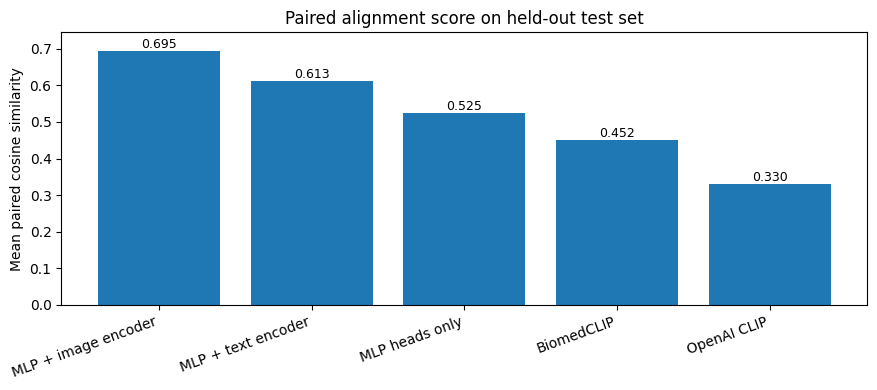

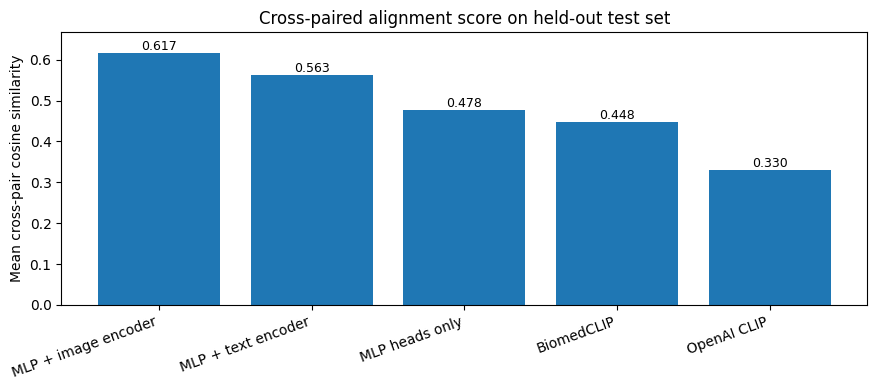

In [ ]:

plot_df = alignment_results.copy()

# Plot 1: paired alignment score
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["paired_similarity"])
ax.set_ylabel("Mean paired cosine similarity")
ax.set_title("Paired alignment score on held-out test set")
ax.set_ylim(min(0, plot_df["paired_similarity"].min() - 0.05),
            plot_df["paired_similarity"].max() + 0.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

# Plot 2: cross-paired alignment score
cross_plot_df = alignment_results.sort_values("cross_pair_similarity", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cross_plot_df["model"], cross_plot_df["cross_pair_similarity"])
ax.set_ylabel("Mean cross-pair cosine similarity")
ax.set_title("Cross-paired alignment score on held-out test set")
ax.set_ylim(min(0, cross_plot_df["cross_pair_similarity"].min() - 0.05),
            cross_plot_df["cross_pair_similarity"].max() + 0.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()


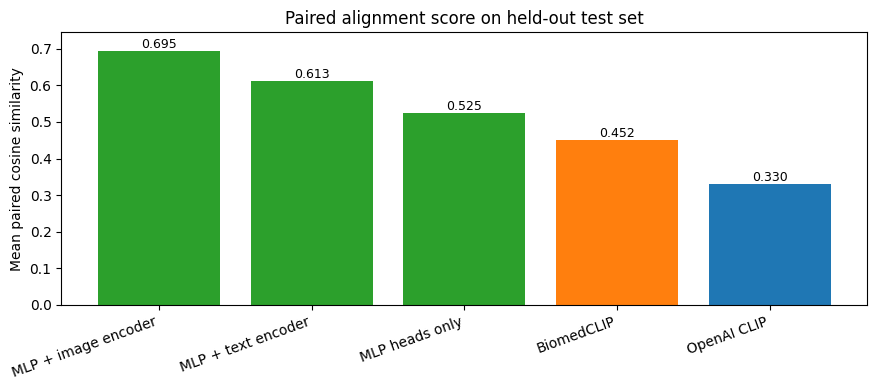

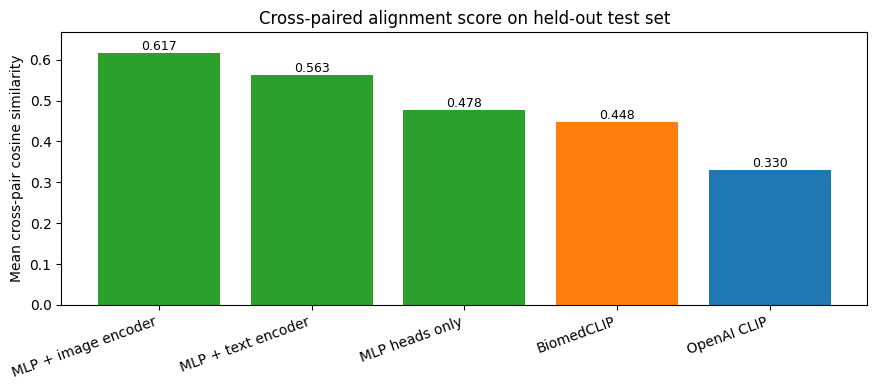

In [ ]:
# Define colors per model (edit names if needed)
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only": "#2ca02c",
    "Image encoder finetuned": "#d62728",
    "Text encoder finetuned": "#9467bd",
}

# Default color for trained models
default_trained_color = "#2ca02c"  # green

def get_colors(models):
    return [
        model_colors[m] if m in model_colors else default_trained_color
        for m in models
    ]


# -----------------------
# Plot 1: paired alignment
# -----------------------
plot_df = alignment_results.copy()
colors = get_colors(plot_df["model"])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["paired_similarity"], color=colors)

ax.set_ylabel("Mean paired cosine similarity")
ax.set_title("Paired alignment score on held-out test set")

ax.set_ylim(
    min(0, plot_df["paired_similarity"].min() - 0.05),
    plot_df["paired_similarity"].max() + 0.05
)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


# -----------------------
# Plot 2: cross-paired alignment
# -----------------------
cross_plot_df = alignment_results.sort_values("cross_pair_similarity", ascending=False).reset_index(drop=True)
colors = get_colors(cross_plot_df["model"])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cross_plot_df["model"], cross_plot_df["cross_pair_similarity"], color=colors)

ax.set_ylabel("Mean cross-pair cosine similarity")
ax.set_title("Cross-paired alignment score on held-out test set")

ax.set_ylim(
    min(0, cross_plot_df["cross_pair_similarity"].min() - 0.05),
    cross_plot_df["cross_pair_similarity"].max() + 0.05
)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

## Classification via image-to-label prompt alignment (labeled test subset only)

Classification is evaluated only on `labeled_test_df`, which is the subset of the held-out test split that contains valid labels. This keeps the split consistent with `experiment_Mar21.ipynb` while avoiding unlabeled datasets during label-prompt evaluation.

In [ ]:

if len(labeled_test_df) == 0:
    raise ValueError("No labeled rows are available in the held-out test split, so classification cannot be evaluated.")

label_names = sorted(labeled_test_df["label"].dropna().astype(str).str.lower().unique().tolist())
label_prompts = {label: build_label_prompt(label) for label in label_names}

print("Label prompts used for classification:")
for label, prompt in label_prompts.items():
    print(f"  {label:12s} -> {prompt}")


Label prompts used for classification:
  benign       -> An ultrasound image of liver with benign findings.
  malignant    -> An ultrasound image of liver with malignant findings.
  normal       -> An ultrasound image of liver with normal findings.


In [ ]:
classification_rows = []
classification_details = {}

# OpenAI CLIP
acc, y_true, y_pred = classify_with_openai_clip(
    labeled_test_df, label_prompts, openai_clip_model, openai_clip_processor, device, batch_size=config["batch_size"]
)
classification_rows.append({"model": "OpenAI CLIP", "accuracy": acc})
classification_details["OpenAI CLIP"] = (y_true, y_pred)

# BiomedCLIP
acc, y_true, y_pred = classify_with_biomedclip(
    labeled_test_df, label_prompts, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device, batch_size=config["batch_size"]
)
classification_rows.append({"model": "BiomedCLIP", "accuracy": acc})
classification_details["BiomedCLIP"] = (y_true, y_pred)

# Trained models
for model_name, model in trained_models.items():
    acc, y_true, y_pred = classify_with_trained_model(
        model, labeled_test_loader, label_prompts, tokenizer, device
    )
    classification_rows.append({"model": model_name, "accuracy": acc})
    classification_details[model_name] = (y_true, y_pred)

classification_results = pd.DataFrame(classification_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
classification_results

OpenAI CLIP classification:   0%|          | 0/23 [00:00<?, ?it/s]

BiomedCLIP classification:   0%|          | 0/23 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/23 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/23 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/23 [00:00<?, ?it/s]

,model,accuracy
0,MLP + image encoder,0.625850
1,MLP + text encoder,0.586395
2,MLP heads only,0.493878
3,BiomedCLIP,0.359184
4,OpenAI CLIP,0.300680


In [ ]:
y_true, y_pred = classification_details["MLP + text encoder"]
print("y_true unique:", sorted(set(y_true)))
print("y_pred unique:", sorted(set(y_pred)))
print("y_true sample:", y_true[:10])
print("y_pred sample:", y_pred[:10])

# Confusion matrix会告诉我们model是不是塌缩到一个class
from collections import Counter
print("\ny_true distribution:", Counter(y_true))
print("y_pred distribution:", Counter(y_pred))

y_true unique: ['benign', 'malignant', 'normal']
y_pred unique: ['benign', 'malignant', 'normal']
y_true sample: ['benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign']
y_pred sample: ['malignant', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'benign', 'normal']

y_true distribution: Counter({'malignant': 435, 'benign': 200, 'normal': 100})
y_pred distribution: Counter({'benign': 329, 'malignant': 261, 'normal': 145})


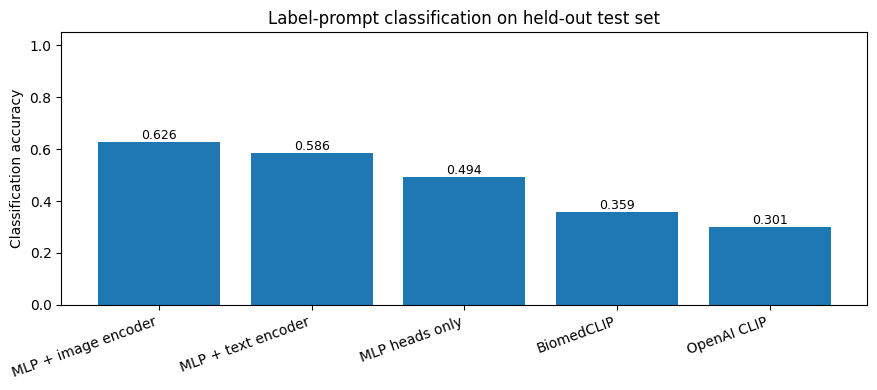

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(classification_results["model"], classification_results["accuracy"])
ax.set_ylabel("Classification accuracy")
ax.set_title("Label-prompt classification on held-out test set")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

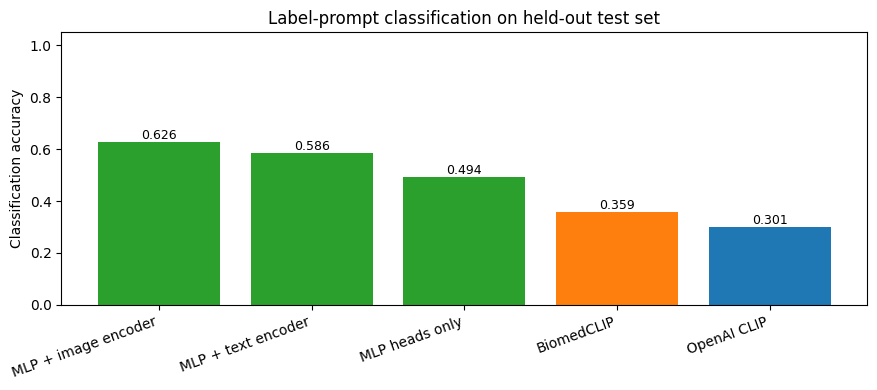

In [ ]:
# Define colors (same mapping as alignment plots)
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only": "#2ca02c",
    "Image encoder finetuned": "#d62728",
    "Text encoder finetuned": "#9467bd",
}

default_trained_color = "#2ca02c"  # green

def get_colors(models):
    return [
        model_colors[m] if m in model_colors else default_trained_color
        for m in models
    ]

# Get colors
colors = get_colors(classification_results["model"])

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(classification_results["model"], classification_results["accuracy"], color=colors)

ax.set_ylabel("Classification accuracy")
ax.set_title("Label-prompt classification on held-out test set")
ax.set_ylim(0, 1.05)

plt.xticks(rotation=20, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## Optional: inspect per-model classification reports

In [ ]:
for model_name in classification_results["model"].tolist():
    print("=" * 80)
    print(model_name)
    y_true, y_pred = classification_details[model_name]
    print(classification_report(y_true, y_pred, digits=4))

MLP + image encoder
              precision    recall  f1-score   support

      benign     0.4055    0.7400    0.5239       200
   malignant     0.9383    0.5241    0.6726       435
      normal     0.6614    0.8400    0.7401       100

    accuracy                         0.6259       735
   macro avg     0.6684    0.7014    0.6455       735
weighted avg     0.7556    0.6259    0.6413       735

MLP + text encoder
              precision    recall  f1-score   support

      benign     0.3951    0.6500    0.4915       200
   malignant     0.9042    0.5425    0.6782       435
      normal     0.4483    0.6500    0.5306       100

    accuracy                         0.5864       735
   macro avg     0.5825    0.6142    0.5668       735
weighted avg     0.7037    0.5864    0.6073       735

MLP heads only
              precision    recall  f1-score   support

      benign     0.3225    0.5950    0.4183       200
   malignant     0.8800    0.4046    0.5543       435
      normal     0.40

In [ ]:
import json
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

# ============================================================
# Save outputs for liver zero-shot evaluation
# ============================================================
results_dir = Path(config["results_dir"])
results_dir.mkdir(parents=True, exist_ok=True)

# --- 1. Build extended summary table with all required metrics ---
summary_rows = []
for model_name, (y_true, y_pred) in classification_details.items():
    summary_rows.append({
        "model":            model_name,
        "n_samples":        len(y_true),
        "n_classes":        len(set(y_true)),
        "accuracy":         accuracy_score(y_true, y_pred),
        "macro_f1":         f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "weighted_f1":      f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision":  precision_score(y_true, y_pred, average="macro",    zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_recall":     recall_score(y_true, y_pred, average="macro",    zero_division=0),
        "weighted_recall":  recall_score(y_true, y_pred, average="weighted", zero_division=0),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
summary_path = results_dir / "liver_zeroshot_summary.csv"
summary_df.to_csv(summary_path, index=False)

# --- 2. Per-row predictions CSV per model ---
# Note: classification_details stores y_true/y_pred in the same order as
# labeled_test_df (the dataloader uses shuffle=False), so we can zip them back.
prediction_paths = []
for model_name, (y_true, y_pred) in classification_details.items():
    safe_name = model_name.replace(" ", "_").replace("+", "and").replace("/", "_")
    pred_df = pd.DataFrame({
        "image_path":  labeled_test_df["image_path"].tolist(),
        "dataset":     labeled_test_df["dataset"].tolist(),
        "true_label":  y_true,
        "pred_label":  y_pred,
        "correct":     [t == p for t, p in zip(y_true, y_pred)],
    })
    p = results_dir / f"liver_zeroshot_predictions_{safe_name}.csv"
    pred_df.to_csv(p, index=False)
    prediction_paths.append(p)

# --- 3. Full per-class classification reports as JSON ---
reports_dict = {}
for model_name, (y_true, y_pred) in classification_details.items():
    reports_dict[model_name] = classification_report(
        y_true, y_pred, digits=4, output_dict=True, zero_division=0,
    )
reports_path = results_dir / "liver_zeroshot_classification_reports.json"
with open(reports_path, "w") as f:
    json.dump(reports_dict, f, indent=2)

# --- 4. Also save the alignment results (already exists) ---
alignment_path = results_dir / "liver_alignment_results.csv"
alignment_results.to_csv(alignment_path, index=False)

# --- 5. Save the prompts used (for reproducibility) ---
prompts_path = results_dir / "liver_label_prompts.json"
with open(prompts_path, "w") as f:
    json.dump(label_prompts, f, indent=2)

# --- 6. Report what we saved ---
print("Saved to:", results_dir)
print(f"  {summary_path.name}")
print(f"  {alignment_path.name}")
print(f"  {prompts_path.name}")
print(f"  {reports_path.name}")
for p in prediction_paths:
    print(f"  {p.name}")

# --- 7. Display the summary table inline ---
print("\nLiver zero-shot summary (sorted by macro F1):")
display_cols = ["model", "accuracy", "macro_f1", "weighted_f1", "macro_precision", "macro_recall"]
summary_df[display_cols].round(4)

Saved to: /content/gdrive/MyDrive/liver_zeroshot_results
  liver_zeroshot_summary.csv
  liver_alignment_results.csv
  liver_label_prompts.json
  liver_zeroshot_classification_reports.json
  liver_zeroshot_predictions_OpenAI_CLIP.csv
  liver_zeroshot_predictions_BiomedCLIP.csv
  liver_zeroshot_predictions_MLP_heads_only.csv
  liver_zeroshot_predictions_MLP_and_image_encoder.csv
  liver_zeroshot_predictions_MLP_and_text_encoder.csv

Liver zero-shot summary (sorted by macro F1):


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,MLP + image encoder,0.6259,0.6455,0.6413,0.6684,0.7014
1,MLP + text encoder,0.5864,0.5668,0.6073,0.5825,0.6142
2,MLP heads only,0.4939,0.4946,0.5115,0.5374,0.5599
3,BiomedCLIP,0.3592,0.3380,0.3692,0.4293,0.4786
4,OpenAI CLIP,0.3007,0.2134,0.1899,0.4987,0.3602


## Extra imports, split prep, organ inference

In [ ]:
# ============================================================
# Few-shot setup: 70/15/15 stratified split within liver holdout
# Test set is held out for ALL downstream evaluation
# (zero-shot, linear probe, few-shot) for apples-to-apples comparison.
# ============================================================
from sklearn.model_selection import train_test_split

# Stratify by label so all 3 classes appear in each split
fs_train_val_df, fs_test_df = train_test_split(
    liver_df,
    test_size=0.15,
    stratify=liver_df["label"],
    random_state=config["random_seed"],
)

# 15 / 85 of remaining = ~17.6%, gives final 70 / 15 / 15
fs_train_df, fs_val_df = train_test_split(
    fs_train_val_df,
    test_size=0.15 / 0.85,
    stratify=fs_train_val_df["label"],
    random_state=config["random_seed"],
)

fs_train_df = fs_train_df.reset_index(drop=True)
fs_val_df   = fs_val_df.reset_index(drop=True)
fs_test_df  = fs_test_df.reset_index(drop=True)

print(f"Liver split sizes (total = {len(liver_df)}):")
print(f"  train: {len(fs_train_df):>4}  ({100*len(fs_train_df)/len(liver_df):.1f}%)")
print(f"  val  : {len(fs_val_df):>4}  ({100*len(fs_val_df)/len(liver_df):.1f}%)")
print(f"  test : {len(fs_test_df):>4}  ({100*len(fs_test_df)/len(liver_df):.1f}%)")

print("\nLabel distribution per split:")
for name, d in [("train", fs_train_df), ("val", fs_val_df), ("test", fs_test_df)]:
    counts = d["label"].value_counts().to_dict()
    print(f"  {name}: {counts}")

Liver split sizes (total = 735):
  train:  513  (69.8%)
  val  :  111  (15.1%)
  test :  111  (15.1%)

Label distribution per split:
  train: {'malignant': 303, 'benign': 140, 'normal': 70}
  val: {'malignant': 66, 'benign': 30, 'normal': 15}
  test: {'malignant': 66, 'benign': 30, 'normal': 15}


In [ ]:
# ============================================================
# Zero-shot classification on fs_test_df (the held-out test split)
# This re-runs zero-shot on the smaller test split so all downstream
# metrics (zero-shot / linear probe / few-shot) share the SAME test set.
# ============================================================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, classification_report,
)

# --- Build prompts (labels already lowercase from data loading) ---
label_names_test = sorted(fs_test_df["label"].unique().tolist())
label_prompts = {l: build_label_prompt(l) for l in label_names_test}
print("Liver prompts:")
for l, p in label_prompts.items():
    print(f"  {l:10s} -> {p}")

# --- DataLoader over fs_test_df only ---
fs_test_dataset = LabeledUltrasoundDataset(fs_test_df, split="test")
fs_test_loader  = DataLoader(
    fs_test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=config["num_workers"],
    pin_memory=(device.type == "cuda"),
)

# --- Run all 5 models ---
zeroshot_details = {}

# OpenAI CLIP
acc, y_true, y_pred = classify_with_openai_clip(
    fs_test_df, label_prompts,
    openai_clip_model, openai_clip_processor, device,
    batch_size=config["batch_size"],
)
zeroshot_details["OpenAI CLIP"] = (y_true, y_pred)

# BiomedCLIP
acc, y_true, y_pred = classify_with_biomedclip(
    fs_test_df, label_prompts,
    biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, device,
    batch_size=config["batch_size"],
)
zeroshot_details["BiomedCLIP"] = (y_true, y_pred)

# Trained EchoCare-CLIP variants
for model_name, model in trained_models.items():
    acc, y_true, y_pred = classify_with_trained_model(
        model, fs_test_loader, label_prompts, tokenizer, device,
    )
    zeroshot_details[model_name] = (y_true, y_pred)

# --- Compute extended metrics ---
zs_summary = []
for model_name, (yt, yp) in zeroshot_details.items():
    zs_summary.append({
        "model":           model_name,
        "setting":         "zero_shot",
        "n_test":          len(yt),
        "accuracy":        accuracy_score(yt, yp),
        "macro_f1":        f1_score(yt, yp, average="macro",    zero_division=0),
        "weighted_f1":     f1_score(yt, yp, average="weighted", zero_division=0),
        "macro_precision": precision_score(yt, yp, average="macro",    zero_division=0),
        "macro_recall":    recall_score(yt, yp, average="macro",    zero_division=0),
    })

zs_summary_df = (
    pd.DataFrame(zs_summary)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
print("\nZero-shot results on fs_test_df (n = {}):".format(len(fs_test_df)))
print(zs_summary_df.round(4).to_string(index=False))

# Per-class breakdown for the best model
best_model_name = zs_summary_df.iloc[0]["model"]
yt, yp = zeroshot_details[best_model_name]
print(f"\nPer-class report — {best_model_name}:")
print(classification_report(yt, yp, digits=4, zero_division=0))

Liver prompts:
  benign     -> An ultrasound image of liver with benign findings.
  malignant  -> An ultrasound image of liver with malignant findings.
  normal     -> An ultrasound image of liver with normal findings.


OpenAI CLIP classification:   0%|          | 0/4 [00:00<?, ?it/s]

BiomedCLIP classification:   0%|          | 0/4 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/4 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/4 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/4 [00:00<?, ?it/s]


Zero-shot results on fs_test_df (n = 111):
              model   setting  n_test  accuracy  macro_f1  weighted_f1  macro_precision  macro_recall
MLP + image encoder zero_shot     111    0.6577    0.6715       0.6757           0.6939        0.7141
 MLP + text encoder zero_shot     111    0.6126    0.5872       0.6361           0.6053        0.6535
     MLP heads only zero_shot     111    0.4595    0.4714       0.4662           0.5561        0.5616
        OpenAI CLIP zero_shot     111    0.3063    0.2689       0.1941           0.5652        0.3990
         BiomedCLIP zero_shot     111    0.2703    0.2445       0.2629           0.3558        0.4040

Per-class report — MLP + image encoder:
              precision    recall  f1-score   support

      benign     0.4259    0.7667    0.5476        30
   malignant     0.9500    0.5758    0.7170        66
      normal     0.7059    0.8000    0.7500        15

    accuracy                         0.6577       111
   macro avg     0.6939    0.71

In [ ]:

# ============================================================
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score

config.update({
    "fewshot_fracs":       [0.01, 0.05, 0.10],
    "fewshot_num_seeds":   5,
    "linear_probe_c_grid": [0.01, 0.1, 1.0, 10.0],
    "probe_max_iter":      3000,
})

# Alias liver splits to peer's variable names + add columns her code expects
labeled_train_df = fs_train_df.copy()
labeled_val_df   = fs_val_df.copy()
labeled_test_df  = fs_test_df.copy()

for d in (labeled_train_df, labeled_val_df, labeled_test_df):
    d["organ"] = "liver"            # required by run_per_organ_probe
    if "row_id" not in d.columns:
        d["row_id"] = np.arange(len(d))   # required by few-shot sampling

print("Liver-only labeled splits (peer-compatible naming):")
print(f"  train: {len(labeled_train_df)}")
print(f"  val  : {len(labeled_val_df)}")
print(f"  test : {len(labeled_test_df)}")

print("\nPer-organ counts (single organ, as expected):")
print(labeled_train_df["organ"].value_counts())

print("\nPer-organ label counts in test split:")
print(labeled_test_df.groupby("organ")["label"].value_counts())

Liver-only labeled splits (peer-compatible naming):
  train: 513
  val  : 111
  test : 111

Per-organ counts (single organ, as expected):
organ
liver    513
Name: count, dtype: int64

Per-organ label counts in test split:
organ  label    
liver  malignant    66
       benign       30
       normal       15
Name: count, dtype: int64


In [ ]:
# Diagnostic: what are the trained models actually predicting?
from collections import Counter

print("Test label distribution (truth):")
print(Counter(fs_test_df["label"].tolist()))

for model_name in ["MLP + text encoder", "MLP heads only", "MLP + image encoder"]:
    yt, yp = zeroshot_details[model_name]
    print(f"\n{model_name}:")
    print(f"  y_true distribution: {Counter(yt)}")
    print(f"  y_pred distribution: {Counter(yp)}")
    print(f"  y_true sample (first 10): {yt[:10]}")
    print(f"  y_pred sample (first 10): {yp[:10]}")

Test label distribution (truth):
Counter({'malignant': 66, 'benign': 30, 'normal': 15})

MLP + text encoder:
  y_true distribution: Counter({'malignant': 66, 'benign': 30, 'normal': 15})
  y_pred distribution: Counter({'benign': 46, 'malignant': 38, 'normal': 27})
  y_true sample (first 10): ['malignant', 'malignant', 'benign', 'normal', 'malignant', 'normal', 'malignant', 'normal', 'malignant', 'malignant']
  y_pred sample (first 10): ['malignant', 'benign', 'benign', 'normal', 'benign', 'benign', 'malignant', 'normal', 'benign', 'malignant']

MLP heads only:
  y_true distribution: Counter({'malignant': 66, 'benign': 30, 'normal': 15})
  y_pred distribution: Counter({'benign': 62, 'normal': 27, 'malignant': 22})
  y_true sample (first 10): ['malignant', 'malignant', 'benign', 'normal', 'malignant', 'normal', 'malignant', 'normal', 'malignant', 'malignant']
  y_pred sample (first 10): ['malignant', 'benign', 'benign', 'normal', 'benign', 'benign', 'benign', 'normal', 'benign', 'maligna

In [ ]:
# Diagnostic 1: confirm config
print("Config check:")
print(f"  img_mean: {config['img_mean']}")
print(f"  img_std:  {config['img_std']}")
print(f"  image_size: {config['image_size']}")

# Diagnostic 2: confirm a trained model embeds something reasonable
import torch
import torch.nn.functional as F

model = trained_models["MLP + text encoder"]
model.eval()

# Encode the 3 prompts
prompt_texts = [label_prompts[l] for l in ["benign", "malignant", "normal"]]
ids, mask = tokenize_texts(prompt_texts, tokenizer, max_length=config["max_seq_len"], device=device)
with torch.no_grad():
    text_embs = model.encode_text(ids, mask)   # (3, D), L2-normalized

print("\nText embedding shape:", text_embs.shape)
print("Text emb norms:", text_embs.norm(dim=-1).cpu().numpy())   # should be ~1.0
print("Text-text similarity matrix (benign / malignant / normal):")
print((text_embs @ text_embs.T).cpu().numpy().round(3))

# Encode a few sample images and compute similarity
sample_df = fs_test_df.iloc[:6]
print("\nSample images (true labels):", sample_df["label"].tolist())

dataset = LabeledUltrasoundDataset(sample_df, split="test")
images = torch.stack([dataset[i][0] for i in range(len(dataset))]).to(device)
with torch.no_grad():
    img_embs = model.encode_image(images)   # (6, D)

print("Image emb shape:", img_embs.shape)
print("Image emb norms:", img_embs.norm(dim=-1).cpu().numpy())   # should be ~1.0

sims = (img_embs @ text_embs.T).cpu().numpy()   # (6, 3)
print("\nSimilarity matrix (rows=images, cols=[benign, malignant, normal]):")
print(sims.round(4))
print("\nArgmax pred (column index → label):")
print([["benign","malignant","normal"][i] for i in sims.argmax(axis=1)])

Config check:
  img_mean: [0.190874, 0.192657, 0.196386]
  img_std:  [0.200044, 0.20141, 0.204307]
  image_size: 256

Text embedding shape: torch.Size([3, 256])
Text emb norms: [1.         0.99999994 1.0000001 ]
Text-text similarity matrix (benign / malignant / normal):
[[1.    0.577 0.452]
 [0.577 1.    0.301]
 [0.452 0.301 1.   ]]

Sample images (true labels): ['malignant', 'malignant', 'benign', 'normal', 'malignant', 'normal']
Image emb shape: torch.Size([6, 256])
Image emb norms: [1.         0.99999994 1.         1.         1.         1.        ]

Similarity matrix (rows=images, cols=[benign, malignant, normal]):
[[0.5545 0.5913 0.5024]
 [0.659  0.5909 0.4597]
 [0.6857 0.5454 0.5881]
 [0.6248 0.4348 0.7129]
 [0.6481 0.5659 0.5945]
 [0.6668 0.5115 0.6149]]

Argmax pred (column index → label):
['malignant', 'benign', 'benign', 'normal', 'benign', 'benign']


## Embedding extraction + probe helpers

In [ ]:
def make_eval_loader(df):
    ds = LabeledUltrasoundDataset(df, split="test")
    return DataLoader(
        ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

@torch.no_grad()
def extract_trained_embeddings(model, df):
    loader = make_eval_loader(df)
    chunks = []
    model.eval()

    for images, _, _, _, _ in tqdm(loader, desc="Trained emb", leave=False):
        images = images.to(device)
        emb = model.encode_image(images)
        chunks.append(emb.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_openai_clip_embeddings(df, model, processor):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(df), config["batch_size"]), desc="OpenAI emb", leave=False):
        batch_df = df.iloc[start:start + config["batch_size"]]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]

        img_inputs = processor(images=pil_images, return_tensors="pt").to(device)

        # More robust than model.get_image_features(...) across notebook/library variants
        vision_out = model.vision_model(pixel_values=img_inputs["pixel_values"])
        pooled = vision_out.pooler_output                    # (B, hidden_dim)
        feats = model.visual_projection(pooled)              # (B, projection_dim)
        feats = F.normalize(feats, dim=-1)

        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_biomedclip_embeddings(df, model, preprocess):
    chunks = []

    for start in tqdm(range(0, len(df), config["batch_size"]), desc="Biomed emb", leave=False):
        batch_df = df.iloc[start:start + config["batch_size"]]
        pil_images = [Image.open(p).convert("RGB") for p in batch_df["image_path"].tolist()]
        images = torch.stack([preprocess(img) for img in pil_images]).to(device)

        feats = model.encode_image(images)
        feats = F.normalize(feats, dim=-1)

        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

def sample_fewshot_per_class(df, frac, seed, label_col="label"):
    pieces = []

    for label, group in df.groupby(label_col):
        n = int(np.ceil(len(group) * frac))
        if len(group) >= 2:
            n = max(2, n)   # avoid one-example classes whenever possible
        else:
            n = 1
        n = min(len(group), n)

        pieces.append(group.sample(n=n, random_state=seed))

    out = pd.concat(pieces, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def multiclass_metrics(y_true, y_pred, y_prob, class_names):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        if len(class_names) == 2:
            pos_class = class_names[1]
            y_true_bin = (np.asarray(y_true) == pos_class).astype(int)
            pos_idx = list(class_names).index(pos_class)
            out["auroc"] = roc_auc_score(y_true_bin, y_prob[:, pos_idx])
        else:
            y_bin = label_binarize(y_true, classes=class_names)
            out["auroc"] = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        out["auroc"] = np.nan

    return out

def fit_best_linear_probe(train_X, train_y, val_X=None, val_y=None, c_grid=None, seed=42):
    c_grid = c_grid or config["linear_probe_c_grid"]

    label_encoder = LabelEncoder()
    label_encoder.fit(train_y)
    y_train = label_encoder.transform(train_y)

    best_model = None
    best_score = -np.inf
    best_c = None

    for c in c_grid:
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                C=c,
                max_iter=config["probe_max_iter"],
                class_weight="balanced",
                solver="lbfgs",
                multi_class="auto",
                random_state=seed,
            )),
        ])

        clf.fit(train_X, y_train)

        if val_X is None or val_y is None or len(val_y) == 0:
            score = 0.0
        else:
            val_mask = np.isin(val_y, label_encoder.classes_)
            if val_mask.sum() == 0:
                score = 0.0
            else:
                y_val = label_encoder.transform(np.asarray(val_y)[val_mask])
                val_pred = clf.predict(val_X[val_mask])
                score = f1_score(y_val, val_pred, average="weighted", zero_division=0)

        if score > best_score:
            best_score = score
            best_model = clf
            best_c = c

    return best_model, label_encoder, best_c, best_score

def evaluate_linear_probe_on_split(clf, label_encoder, X, y):
    y = np.asarray(y)
    keep = np.isin(y, label_encoder.classes_)

    X = X[keep]
    y = y[keep]

    y_pred_int = clf.predict(X)
    y_prob = clf.predict_proba(X)
    y_pred = label_encoder.inverse_transform(y_pred_int)

    metrics = multiclass_metrics(y, y_pred, y_prob, label_encoder.classes_)
    metrics["n_eval"] = int(len(y))
    return metrics

def run_per_organ_probe(train_meta, train_X, val_meta, val_X, test_meta, test_X,
                        fewshot_frac=None, fewshot_seed=42):
    rows = []

    organs = sorted(set(train_meta["organ"]) & set(val_meta["organ"]) & set(test_meta["organ"]))

    for organ in organs:
        tr = train_meta[train_meta["organ"] == organ].copy()
        va = val_meta[val_meta["organ"] == organ].copy()
        te = test_meta[test_meta["organ"] == organ].copy()

        # Require at least 2 training examples per class in the full train split
        train_counts = tr["label"].value_counts()
        keep_classes = train_counts[train_counts >= 2].index.tolist()

        tr = tr[tr["label"].isin(keep_classes)].copy()
        va = va[va["label"].isin(keep_classes)].copy()
        te = te[te["label"].isin(keep_classes)].copy()

        if tr["label"].nunique() < 2 or len(te) == 0:
            print(f"Skipping organ={organ} because there are not enough train/test classes after filtering.")
            continue

        if fewshot_frac is not None:
            tr = sample_fewshot_per_class(tr, frac=fewshot_frac, seed=fewshot_seed, label_col="label")

        X_tr = train_X[tr["row_id"].to_numpy()]
        y_tr = tr["label"].to_numpy()

        X_va = val_X[va["row_id"].to_numpy()]
        y_va = va["label"].to_numpy()

        X_te = test_X[te["row_id"].to_numpy()]
        y_te = te["label"].to_numpy()

        clf, le, best_c, best_val_f1 = fit_best_linear_probe(
            X_tr, y_tr,
            X_va, y_va,
            c_grid=config["linear_probe_c_grid"],
            seed=fewshot_seed,
        )

        test_metrics = evaluate_linear_probe_on_split(clf, le, X_te, y_te)

        rows.append({
            "organ": organ,
            "n_train": len(tr),
            "n_val": len(va),
            "n_test": len(te),
            "n_classes": len(le.classes_),
            "best_c": best_c,
            "val_f1_weighted": best_val_f1,
            **test_metrics,
        })

    return pd.DataFrame(rows)

def summarize_across_organs(per_organ_df):
    if per_organ_df.empty:
        return pd.DataFrame(columns=["average_type", "auroc", "accuracy", "f1_weighted", "n_organs"])

    rows = []
    weights = per_organ_df["n_eval"].to_numpy()

    for avg_name in ["macro", "weighted_by_test_n"]:
        row = {"average_type": avg_name, "n_organs": int(len(per_organ_df))}

        for metric in ["auroc", "accuracy", "f1_weighted"]:
            vals = per_organ_df[metric].to_numpy(dtype=float)
            mask = ~np.isnan(vals)

            if mask.sum() == 0:
                row[metric] = np.nan
            elif avg_name == "macro":
                row[metric] = vals[mask].mean()
            else:
                row[metric] = np.average(vals[mask], weights=weights[mask])

        rows.append(row)

    return pd.DataFrame(rows)

## Extract embeddings for every model and split

In [ ]:
model_registry = {
    "OpenAI CLIP": {"kind": "openai", "model": openai_clip_model},
    "BiomedCLIP": {"kind": "biomedclip", "model": biomedclip_model},
}
for model_name, model in trained_models.items():
    model_registry[model_name] = {"kind": "trained", "model": model}

eval_splits = {
    "train": labeled_train_df,
    "val": labeled_val_df,
    "test": labeled_test_df,
}

embedding_bank = defaultdict(dict)

for model_name, spec in model_registry.items():
    print(f"\nExtracting embeddings for: {model_name}")

    for split_name, split_df in eval_splits.items():
        if spec["kind"] == "trained":
            X = extract_trained_embeddings(spec["model"], split_df)
        elif spec["kind"] == "openai":
            X = extract_openai_clip_embeddings(split_df, openai_clip_model, openai_clip_processor)
        elif spec["kind"] == "biomedclip":
            X = extract_biomedclip_embeddings(split_df, biomedclip_model, biomedclip_preprocess)
        else:
            raise ValueError(f"Unknown model kind: {spec['kind']}")

        embedding_bank[model_name][split_name] = {
            "X": X,
            "meta": split_df.copy().reset_index(drop=True),
        }

        print(f"  {split_name:>5s}: {X.shape}")


Extracting embeddings for: OpenAI CLIP


OpenAI emb:   0%|          | 0/17 [00:00<?, ?it/s]

  train: (513, 512)


OpenAI emb:   0%|          | 0/4 [00:00<?, ?it/s]

    val: (111, 512)


...

  train: (513, 256)


Trained emb:   0%|          | 0/4 [00:00<?, ?it/s]

    val: (111, 256)


Trained emb:   0%|          | 0/4 [00:00<?, ?it/s]

   test: (111, 256)


## Full linear probe evaluation

In [ ]:
linear_probe_per_organ = []
linear_probe_aggregate = []

for model_name in model_registry:
    print(f"\nRunning full linear probe for: {model_name}")

    train_pack = embedding_bank[model_name]["train"]
    val_pack   = embedding_bank[model_name]["val"]
    test_pack  = embedding_bank[model_name]["test"]

    per_organ = run_per_organ_probe(
        train_pack["meta"], train_pack["X"],
        val_pack["meta"],   val_pack["X"],
        test_pack["meta"],  test_pack["X"],
        fewshot_frac=None,
        fewshot_seed=config["random_seed"],
    )
    per_organ["model"] = model_name
    per_organ["setting"] = "linear_probe"
    linear_probe_per_organ.append(per_organ)

    agg = summarize_across_organs(per_organ)
    agg["model"] = model_name
    agg["setting"] = "linear_probe"
    linear_probe_aggregate.append(agg)

linear_probe_per_organ = pd.concat(linear_probe_per_organ, ignore_index=True)
linear_probe_aggregate = pd.concat(linear_probe_aggregate, ignore_index=True)

print("\nPer-organ linear probe results:")
linear_probe_per_organ.sort_values(["model", "organ"])[
    ["model", "organ", "auroc", "accuracy", "f1_weighted", "n_train", "n_test", "n_classes"]
]

print("\nAggregate linear probe results:")
linear_probe_aggregate.sort_values(["average_type", "auroc"], ascending=[True, False])[
    ["model", "average_type", "auroc", "accuracy", "f1_weighted", "n_organs"]
]


Running full linear probe for: OpenAI CLIP

Running full linear probe for: BiomedCLIP

Running full linear probe for: MLP heads only

Running full linear probe for: MLP + image encoder

Running full linear probe for: MLP + text encoder

Per-organ linear probe results:

Aggregate linear probe results:


,model,average_type,auroc,accuracy,f1_weighted,n_organs
8,MLP + text encoder,macro,0.868372,0.720721,0.717420,1
6,MLP + image encoder,macro,0.862932,0.720721,0.725431,1
4,MLP heads only,macro,0.861764,0.702703,0.698616,1
0,OpenAI CLIP,macro,0.798777,0.684685,0.683403,1
2,BiomedCLIP,macro,0.728984,0.639640,0.638064,1
9,MLP + text encoder,weighted_by_test_n,0.868372,0.720721,0.717420,1
7,MLP + image encoder,weighted_by_test_n,0.862932,0.720721,0.725431,1
5,MLP heads only,weighted_by_test_n,0.861764,0.702703,0.698616,1
1,OpenAI CLIP,weighted_by_test_n,0.798777,0.684685,0.683403,1
3,BiomedCLIP,weighted_by_test_n,0.728984,0.639640,0.638064,1


## Few-shot adaptation evaluation

In [ ]:
fewshot_raw_rows = []

for model_name in model_registry:
    print(f"\nFew-shot evaluation for: {model_name}")

    train_pack = embedding_bank[model_name]["train"]
    val_pack   = embedding_bank[model_name]["val"]
    test_pack  = embedding_bank[model_name]["test"]

    for frac in config["fewshot_fracs"]:
        print(f"  fraction = {frac:.0%}")

        for rep in range(config["fewshot_num_seeds"]):
            seed = config["random_seed"] + rep

            per_organ = run_per_organ_probe(
                train_pack["meta"], train_pack["X"],
                val_pack["meta"],   val_pack["X"],
                test_pack["meta"],  test_pack["X"],
                fewshot_frac=frac,
                fewshot_seed=seed,
            )

            per_organ["model"] = model_name
            per_organ["setting"] = "fewshot_adaptation"
            per_organ["fewshot_frac"] = frac
            per_organ["seed"] = seed

            fewshot_raw_rows.append(per_organ)

fewshot_per_organ_raw = pd.concat(fewshot_raw_rows, ignore_index=True)

fewshot_per_organ_summary = (
    fewshot_per_organ_raw
    .groupby(["model", "setting", "fewshot_frac", "organ"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_train_mean=("n_train", "mean"),
        n_test_mean=("n_test", "mean"),
        n_classes_mean=("n_classes", "mean"),
    )
)

fewshot_aggregate_rows = []

for (model_name, frac, seed), df_seed in fewshot_per_organ_raw.groupby(["model", "fewshot_frac", "seed"]):
    agg = summarize_across_organs(df_seed)
    agg["model"] = model_name
    agg["setting"] = "fewshot_adaptation"
    agg["fewshot_frac"] = frac
    agg["seed"] = seed
    fewshot_aggregate_rows.append(agg)

fewshot_aggregate_raw = pd.concat(fewshot_aggregate_rows, ignore_index=True)

fewshot_aggregate_summary = (
    fewshot_aggregate_raw
    .groupby(["model", "setting", "fewshot_frac", "average_type"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_organs_mean=("n_organs", "mean"),
    )
)

print("\nFew-shot aggregate summary:")
fewshot_aggregate_summary.sort_values(
    ["average_type", "fewshot_frac", "auroc_mean"],
    ascending=[True, True, False]
)[
    ["model", "fewshot_frac", "average_type",
     "auroc_mean", "auroc_std",
     "accuracy_mean", "accuracy_std",
     "f1_weighted_mean", "f1_weighted_std"]
]


Few-shot evaluation for: OpenAI CLIP
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: BiomedCLIP
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: MLP heads only
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: MLP + image encoder
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot evaluation for: MLP + text encoder
  fraction = 1%
  fraction = 5%
  fraction = 10%

Few-shot aggregate summary:


,model,fewshot_frac,average_type,auroc_mean,auroc_std,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std
6,MLP + image encoder,0.01,macro,0.821159,0.024134,0.688288,0.018681,0.690878,0.015901
12,MLP + text encoder,0.01,macro,0.757818,0.059804,0.598198,0.062286,0.595474,0.059305
18,MLP heads only,0.01,macro,0.744121,0.077331,0.572973,0.099833,0.572435,0.096072
24,OpenAI CLIP,0.01,macro,0.660100,0.143304,0.603604,0.096190,0.580355,0.090332
0,BiomedCLIP,0.01,macro,0.656764,0.063829,0.536937,0.087947,0.537456,0.074781
8,MLP + image encoder,0.05,macro,0.838973,0.034986,0.699099,0.041087,0.699483,0.045329
14,MLP + text encoder,0.05,macro,0.788333,0.049157,0.648649,0.061433,0.654899,0.059353
20,MLP heads only,0.05,macro,0.786883,0.022223,0.654054,0.043487,0.660741,0.042632
2,BiomedCLIP,0.05,macro,0.724054,0.026758,0.630631,0.040790,0.629186,0.031244
26,OpenAI CLIP,0.05,macro,0.721256,0.052140,0.630631,0.068314,0.626329,0.068258


## Cell 6 — save tables and make simple plots

Saved to: /kaggle/working/heldout_probe_eval


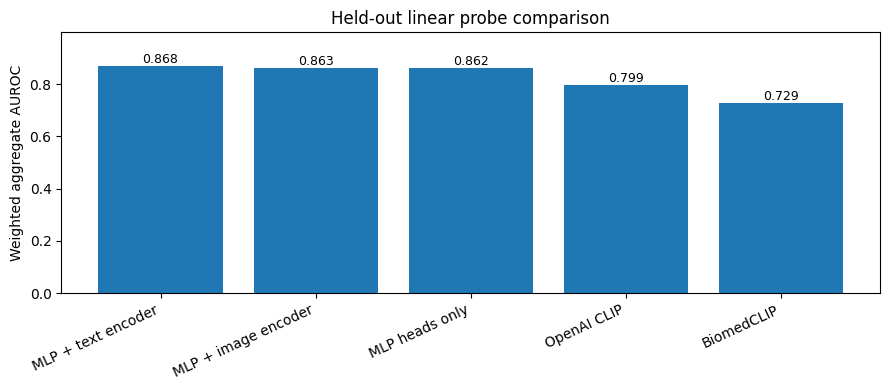

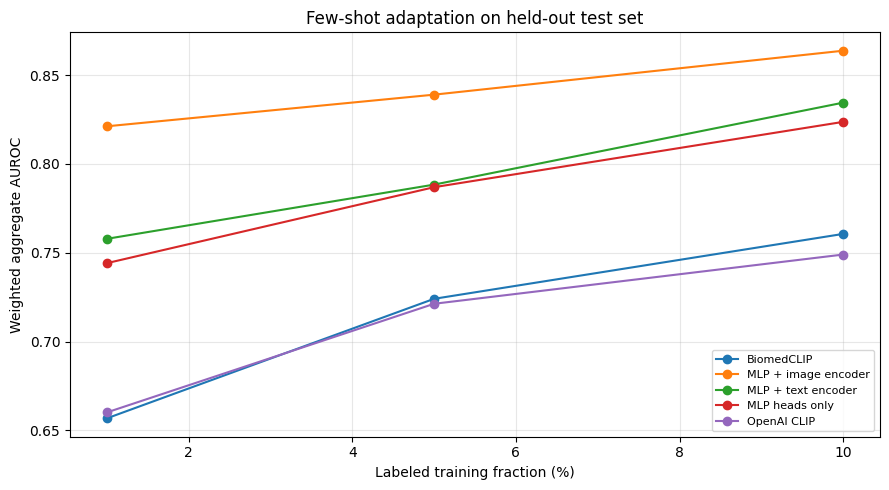

In [ ]:
results_dir = Path("/kaggle/working/heldout_probe_eval")
results_dir.mkdir(parents=True, exist_ok=True)

linear_probe_per_organ.to_csv(results_dir / "linear_probe_per_organ.csv", index=False)
linear_probe_aggregate.to_csv(results_dir / "linear_probe_aggregate.csv", index=False)

fewshot_per_organ_raw.to_csv(results_dir / "fewshot_per_organ_raw.csv", index=False)
fewshot_per_organ_summary.to_csv(results_dir / "fewshot_per_organ_summary.csv", index=False)

fewshot_aggregate_raw.to_csv(results_dir / "fewshot_aggregate_raw.csv", index=False)
fewshot_aggregate_summary.to_csv(results_dir / "fewshot_aggregate_summary.csv", index=False)

print("Saved to:", results_dir)

# --- Plot 1: full linear probe aggregate AUROC ---
plot_df = linear_probe_aggregate[
    linear_probe_aggregate["average_type"] == "weighted_by_test_n"
].copy().sort_values("auroc", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(plot_df["model"], plot_df["auroc"])
ax.set_ylabel("Weighted aggregate AUROC")
ax.set_title("Held-out linear probe comparison")
ax.set_ylim(0, min(1.0, max(0.05, plot_df["auroc"].max() * 1.15)))
plt.xticks(rotation=25, ha="right")

for b in bars:
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{b.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# --- Plot 2: few-shot weighted aggregate AUROC curves ---
plot_df = fewshot_aggregate_summary[
    fewshot_aggregate_summary["average_type"] == "weighted_by_test_n"
].copy()

fig, ax = plt.subplots(figsize=(9, 5))
for model_name in plot_df["model"].unique():
    sub = plot_df[plot_df["model"] == model_name].sort_values("fewshot_frac")
    ax.plot(sub["fewshot_frac"] * 100, sub["auroc_mean"], marker="o", label=model_name)

ax.set_xlabel("Labeled training fraction (%)")
ax.set_ylabel("Weighted aggregate AUROC")
ax.set_title("Few-shot adaptation on held-out test set")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import shutil
from pathlib import Path

src = Path("/kaggle/working/heldout_probe_eval")  # check 这个path实际存不存在
if not src.exists():
    src = Path("/content/heldout_probe_eval")     # alternative location

if not src.exists():
    # Just look for it
    import subprocess
    result = subprocess.run(["find", "/", "-name", "heldout_probe_eval", "-type", "d"],
                            capture_output=True, text=True, timeout=30)
    print("Found at:", result.stdout)
else:
    dst = Path("/content/gdrive/MyDrive/liver_zeroshot_results/fewshot_eval")
    dst.mkdir(parents=True, exist_ok=True)

    for f in src.iterdir():
        if f.is_file():
            shutil.copy(f, dst / f.name)
            print(f"Copied: {f.name}")

    print(f"\nDone. Files now in: {dst}")
    print("\nFiles:")
    for f in sorted(dst.iterdir()):
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

Copied: linear_probe_per_organ.csv
Copied: fewshot_aggregate_raw.csv
Copied: linear_probe_aggregate.csv
Copied: fewshot_per_organ_summary.csv
Copied: fewshot_per_organ_raw.csv
Copied: fewshot_aggregate_summary.csv

Done. Files now in: /content/gdrive/MyDrive/liver_zeroshot_results/fewshot_eval

Files:
  fewshot_aggregate_raw.csv  (16.7 KB)
  fewshot_aggregate_summary.csv  (5.2 KB)
  fewshot_per_organ_raw.csv  (10.7 KB)
  fewshot_per_organ_summary.csv  (2.7 KB)
  linear_probe_aggregate.csv  (1.0 KB)
  linear_probe_per_organ.csv  (0.8 KB)


## Additional suggested tests

The core linear-probe / few-shot comparison is the right next step, but it is not enough by itself.

These extra tests are worth running because they answer different questions:

- **Retrieval quality on held-out image-caption pairs**: checks whether matched pairs rank above mismatched pairs, which is closer to the original alignment objective than plain classification.
- **Bootstrap confidence intervals**: shows whether small ranking differences are likely real or just split noise.
- **Confusion-matrix diagnostics**: shows *where* each model fails within each organ, instead of hiding all failures inside a single AUROC or F1.

None of these replaces external validation, but they make your internal evaluation much harder to hand-wave.

### Test 1 — Held-out retrieval metrics (image→text and text→image)

In [ ]:
# Extra test: retrieval metrics on held-out paired image-caption examples

def compute_recall_at_k(sim_matrix, ks=(1, 5, 10)):
    """
    Assumes row i matches column i.
    Returns recall@k for row-to-column retrieval.
    """
    n = sim_matrix.shape[0]
    order = np.argsort(-sim_matrix, axis=1)
    out = {}
    targets = np.arange(n)

    for k in ks:
        topk = order[:, :min(k, n)]
        hit = (topk == targets[:, None]).any(axis=1)
        out[f"R@{k}"] = float(hit.mean())

    return out

@torch.no_grad()
def extract_trained_text_embeddings(model, texts, tokenizer, batch_size=32):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(texts), batch_size), desc="Trained text emb", leave=False):
        batch_texts = list(texts[start:start + batch_size])
        ids, mask = tokenize_texts(batch_texts, tokenizer, max_length=config["max_seq_len"], device=device)
        txt_emb = model.encode_text(ids, mask)
        chunks.append(txt_emb.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_openai_clip_text_embeddings(texts, model, processor, batch_size=32):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(texts), batch_size), desc="OpenAI text emb", leave=False):
        batch_texts = list(texts[start:start + batch_size])
        text_inputs = processor(text=batch_texts, return_tensors="pt", padding=True, truncation=True).to(device)

        txt_out = model.text_model(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"],
        )
        pooled = txt_out.pooler_output
        feats = model.text_projection(pooled)
        feats = F.normalize(feats, dim=-1)

        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

@torch.no_grad()
def extract_biomedclip_text_embeddings(texts, model, tokenizer, batch_size=32):
    model.eval()
    chunks = []

    for start in tqdm(range(0, len(texts), batch_size), desc="Biomed text emb", leave=False):
        batch_texts = list(texts[start:start + batch_size])
        text_inputs = tokenizer(batch_texts, context_length=256).to(device)
        feats = model.encode_text(text_inputs)
        feats = F.normalize(feats, dim=-1)
        chunks.append(feats.cpu().numpy())

    return np.concatenate(chunks, axis=0)

def run_retrieval_eval_for_model(model_name, spec, df):
    # image embeddings
    if spec["kind"] == "trained":
        img_X = extract_trained_embeddings(spec["model"], df)
        txt_X = extract_trained_text_embeddings(
            spec["model"], df["caption"].tolist(), tokenizer, batch_size=config["batch_size"]
        )
    elif spec["kind"] == "openai":
        img_X = extract_openai_clip_embeddings(df, openai_clip_model, openai_clip_processor)
        txt_X = extract_openai_clip_text_embeddings(
            df["caption"].tolist(), openai_clip_model, openai_clip_processor, batch_size=config["batch_size"]
        )
    elif spec["kind"] == "biomedclip":
        img_X = extract_biomedclip_embeddings(df, biomedclip_model, biomedclip_preprocess)
        txt_X = extract_biomedclip_text_embeddings(
            df["caption"].tolist(), biomedclip_model, biomedclip_tokenizer, batch_size=config["batch_size"]
        )
    else:
        raise ValueError(f"Unknown model kind: {spec['kind']}")

    sim = img_X @ txt_X.T
    i2t = compute_recall_at_k(sim, ks=(1, 5, 10))
    t2i = compute_recall_at_k(sim.T, ks=(1, 5, 10))

    row = {"model": model_name}
    row.update({f"image_to_text_{k}": v for k, v in i2t.items()})
    row.update({f"text_to_image_{k}": v for k, v in t2i.items()})
    return row

retrieval_rows = []
for model_name, spec in model_registry.items():
    print(f"Running retrieval metrics for {model_name}")
    retrieval_rows.append(run_retrieval_eval_for_model(model_name, spec, test_df))

retrieval_results = (
    pd.DataFrame(retrieval_rows)
    .sort_values(["image_to_text_R@1", "text_to_image_R@1"], ascending=False)
    .reset_index(drop=True)
)
retrieval_results

Running retrieval metrics for OpenAI CLIP


OpenAI emb:   0%|          | 0/23 [00:00<?, ?it/s]

OpenAI text emb:   0%|          | 0/23 [00:00<?, ?it/s]

Running retrieval metrics for BiomedCLIP


Biomed emb:   0%|          | 0/23 [00:00<?, ?it/s]

...

Trained text emb:   0%|          | 0/23 [00:00<?, ?it/s]

Running retrieval metrics for MLP + text encoder


Trained emb:   0%|          | 0/23 [00:00<?, ?it/s]

Trained text emb:   0%|          | 0/23 [00:00<?, ?it/s]

,model,image_to_text_R@1,image_to_text_R@5,image_to_text_R@10,text_to_image_R@1,text_to_image_R@5,text_to_image_R@10
0,MLP heads only,0.006803,0.024490,0.043537,0.006803,0.028571,0.043537
1,MLP + image encoder,0.005442,0.019048,0.047619,0.004082,0.021769,0.042177
2,MLP + text encoder,0.004082,0.017687,0.032653,0.009524,0.017687,0.050340
3,BiomedCLIP,0.001361,0.006803,0.016327,0.004082,0.009524,0.020408
4,OpenAI CLIP,0.000000,0.006803,0.010884,0.000000,0.005442,0.020408


### Test 2 — Bootstrap confidence intervals for held-out aggregate probe metrics

In [ ]:
# Extra test: bootstrap confidence intervals for aggregate linear-probe metrics

def bootstrap_metric_ci(values, n_boot=1000, alpha=0.05, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = []
    n = len(values)

    for _ in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boots.append(sample.mean())

    boots = np.asarray(boots)
    mean = float(values.mean())
    lo = float(np.quantile(boots, alpha / 2))
    hi = float(np.quantile(boots, 1 - alpha / 2))
    return mean, lo, hi

ci_rows = []
agg_df = linear_probe_per_organ.copy()

for model_name, sub in agg_df.groupby("model"):
    for metric in ["auroc", "accuracy", "f1_weighted"]:
        mean, lo, hi = bootstrap_metric_ci(sub[metric].values, n_boot=1000, alpha=0.05, seed=config["random_seed"])
        ci_rows.append({
            "model": model_name,
            "setting": "linear_probe",
            "metric": metric,
            "mean": mean,
            "ci_lower": lo,
            "ci_upper": hi,
            "n_organs": int(sub["organ"].nunique()),
        })

linear_probe_ci = pd.DataFrame(ci_rows)
linear_probe_ci

,model,setting,metric,mean,ci_lower,ci_upper,n_organs
0,BiomedCLIP,linear_probe,auroc,0.728984,0.728984,0.728984,1
1,BiomedCLIP,linear_probe,accuracy,0.639640,0.639640,0.639640,1
2,BiomedCLIP,linear_probe,f1_weighted,0.638064,0.638064,0.638064,1
3,MLP + image encoder,linear_probe,auroc,0.862932,0.862932,0.862932,1
4,MLP + image encoder,linear_probe,accuracy,0.720721,0.720721,0.720721,1
5,MLP + image encoder,linear_probe,f1_weighted,0.725431,0.725431,0.725431,1
6,MLP + text encoder,linear_probe,auroc,0.868372,0.868372,0.868372,1
7,MLP + text encoder,linear_probe,accuracy,0.720721,0.720721,0.720721,1
8,MLP + text encoder,linear_probe,f1_weighted,0.717420,0.717420,0.717420,1
9,MLP heads only,linear_probe,auroc,0.861764,0.861764,0.861764,1


In [ ]:
import shutil
from pathlib import Path

# Save retrieval results to Drive
results_dir = Path("/content/gdrive/MyDrive/liver_zeroshot_results")
retrieval_results.to_csv(results_dir / "liver_retrieval_results.csv", index=False)
print(f"Saved: {results_dir / 'liver_retrieval_results.csv'}")
print("\nContents:")
print(retrieval_results.round(4).to_string(index=False))

Saved: /content/gdrive/MyDrive/liver_zeroshot_results/liver_retrieval_results.csv

Contents:
              model  image_to_text_R@1  image_to_text_R@5  image_to_text_R@10  text_to_image_R@1  text_to_image_R@5  text_to_image_R@10
     MLP heads only             0.0068             0.0245              0.0435             0.0068             0.0286              0.0435
MLP + image encoder             0.0054             0.0190              0.0476             0.0041             0.0218              0.0422
 MLP + text encoder             0.0041             0.0177              0.0327             0.0095             0.0177              0.0503
         BiomedCLIP             0.0014             0.0068              0.0163             0.0041             0.0095              0.0204
        OpenAI CLIP             0.0000             0.0068              0.0109             0.0000             0.0054              0.0204


### Test 3 — Confusion matrices for the best held-out linear-probe models by organ

In [ ]:
# Extra test: confusion-matrix diagnostics for the best linear-probe model in each organ

from sklearn.metrics import ConfusionMatrixDisplay

def fit_and_predict_probe_for_one_organ(model_name, organ):
    train_pack = embedding_bank[model_name]["train"]
    val_pack   = embedding_bank[model_name]["val"]
    test_pack  = embedding_bank[model_name]["test"]

    tr = train_pack["meta"][train_pack["meta"]["organ"] == organ].copy()
    va = val_pack["meta"][val_pack["meta"]["organ"] == organ].copy()
    te = test_pack["meta"][test_pack["meta"]["organ"] == organ].copy()

    train_counts = tr["label"].value_counts()
    keep_classes = train_counts[train_counts >= 2].index.tolist()

    tr = tr[tr["label"].isin(keep_classes)].copy()
    va = va[va["label"].isin(keep_classes)].copy()
    te = te[te["label"].isin(keep_classes)].copy()

    if tr["label"].nunique() < 2 or len(te) == 0:
        return None

    X_tr = train_pack["X"][tr["row_id"].to_numpy()]
    y_tr = tr["label"].to_numpy()

    X_va = val_pack["X"][va["row_id"].to_numpy()]
    y_va = va["label"].to_numpy()

    X_te = test_pack["X"][te["row_id"].to_numpy()]
    y_te = te["label"].to_numpy()

    clf, le, best_c, best_val_f1 = fit_best_linear_probe(
        X_tr, y_tr,
        X_va, y_va,
        c_grid=config["linear_probe_c_grid"],
        seed=config["random_seed"],
    )

    keep = np.isin(y_te, le.classes_)
    X_te = X_te[keep]
    y_te = y_te[keep]

    y_pred_int = clf.predict(X_te)
    y_pred = le.inverse_transform(y_pred_int)

    return {
        "y_true": y_te,
        "y_pred": y_pred,
        "labels": list(le.classes_),
        "best_c": best_c,
        "val_f1_weighted": best_val_f1,
    }

best_by_organ = (
    linear_probe_per_organ.sort_values(["organ", "f1_weighted"], ascending=[True, False])
    .groupby("organ", as_index=False)
    .first()[["organ", "model", "f1_weighted", "auroc", "accuracy"]]
)
best_by_organ

,organ,model,f1_weighted,auroc,accuracy
0,liver,MLP + image encoder,0.725431,0.862932,0.720721


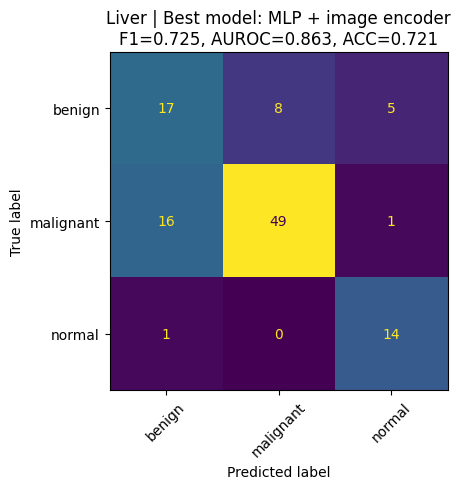

In [ ]:
for _, row in best_by_organ.iterrows():
    organ = row["organ"]
    model_name = row["model"]

    out = fit_and_predict_probe_for_one_organ(model_name, organ)
    if out is None:
        print(f"Skipping {organ}: not enough data after filtering")
        continue

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(
        out["y_true"],
        out["y_pred"],
        labels=out["labels"],
        xticks_rotation=45,
        ax=ax,
        colorbar=False,
    )
    ax.set_title(
        f"{organ.capitalize()} | Best model: {model_name}\n"
        f"F1={row['f1_weighted']:.3f}, AUROC={row['auroc']:.3f}, ACC={row['accuracy']:.3f}"
    )
    plt.tight_layout()
    plt.show()

## Additional analysis: per-organ and per-dataset classification

These added cells:
1. summarize the label space for each **organ** and **dataset** in the held-out labeled test split,
2. run the same prompt-based classification separately within each organ / dataset subset,
3. draw grouped bar plots with models clustered within each organ / dataset,
4. save the per-group results tables.

These cells do **not** modify any earlier cells; they only add extra analysis.


In [ ]:

# Per-organ / per-dataset label-space summary

def summarize_group_label_space(df, group_col):
    rows = []
    for group_name, sub_df in df.groupby(group_col):
        labels = sorted(sub_df["label"].dropna().astype(str).str.lower().unique().tolist())
        rows.append({
            group_col: group_name,
            "n_samples": int(len(sub_df)),
            "labels": ", ".join(labels),
            "n_labels": int(len(labels)),
            "task_type": "binary" if len(labels) == 2 else ("single-class" if len(labels) == 1 else f"{len(labels)}-class"),
        })
    return pd.DataFrame(rows).sort_values([group_col]).reset_index(drop=True)

organ_label_space = summarize_group_label_space(labeled_test_df, "organ")
dataset_label_space = summarize_group_label_space(labeled_test_df, "dataset")

print("Per-organ label space in held-out labeled test set")
display(organ_label_space)

print("Per-dataset label space in held-out labeled test set")
display(dataset_label_space)


Per-organ label space in held-out labeled test set


,organ,n_samples,labels,n_labels,task_type
0,liver,111,"benign, malignant, normal",3,3-class


Per-dataset label space in held-out labeled test set


,dataset,n_samples,labels,n_labels,task_type
0,liver_holdout,111,"benign, malignant, normal",3,3-class


In [ ]:

# Separate prompt-based classification within each organ / dataset subset

def make_subset_labeled_loader(df):
    ds = LabeledUltrasoundDataset(df.reset_index(drop=True), split="test")
    return DataLoader(
        ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=(device.type == "cuda"),
    )

def get_model_device_fallback(model, default_device):
    try:
        return next(model.parameters()).device
    except StopIteration:
        return default_device
    except Exception:
        return default_device

openai_eval_device = get_model_device_fallback(openai_clip_model, device)
biomed_eval_device = get_model_device_fallback(biomedclip_model, device)

def evaluate_prompt_classification_by_group(df, group_col):
    rows = []
    details = {}

    for group_name, sub_df in sorted(df.groupby(group_col), key=lambda x: str(x[0])):
        sub_df = sub_df.reset_index(drop=True).copy()
        label_names = sorted(sub_df["label"].dropna().astype(str).str.lower().unique().tolist())

        # skip groups with <2 labels because "classification accuracy" is trivial / uninformative there
        if len(label_names) < 2:
            print(f"Skipping {group_col}={group_name!r} because it has <2 labels.")
            continue

        label_prompts = {label: build_label_prompt(label) for label in label_names}

        # OpenAI CLIP
        acc, y_true, y_pred = classify_with_openai_clip(
            sub_df, label_prompts, openai_clip_model, openai_clip_processor,
            openai_eval_device, batch_size=config["batch_size"]
        )
        rows.append({
            "group_type": group_col,
            "group_name": group_name,
            "model": "OpenAI CLIP",
            "accuracy": acc,
            "n_samples": int(len(sub_df)),
            "n_labels": int(len(label_names)),
            "labels": ", ".join(label_names),
        })
        details[(group_col, group_name, "OpenAI CLIP")] = (y_true, y_pred)

        # BiomedCLIP
        acc, y_true, y_pred = classify_with_biomedclip(
            sub_df, label_prompts, biomedclip_model, biomedclip_preprocess,
            biomedclip_tokenizer, biomed_eval_device, batch_size=config["batch_size"]
        )
        rows.append({
            "group_type": group_col,
            "group_name": group_name,
            "model": "BiomedCLIP",
            "accuracy": acc,
            "n_samples": int(len(sub_df)),
            "n_labels": int(len(label_names)),
            "labels": ", ".join(label_names),
        })
        details[(group_col, group_name, "BiomedCLIP")] = (y_true, y_pred)

        # Trained models
        subset_loader = make_subset_labeled_loader(sub_df)
        for model_name, model in trained_models.items():
            trained_eval_device = get_model_device_fallback(model, device)
            acc, y_true, y_pred = classify_with_trained_model(
                model, subset_loader, label_prompts, tokenizer, trained_eval_device
            )
            rows.append({
                "group_type": group_col,
                "group_name": group_name,
                "model": model_name,
                "accuracy": acc,
                "n_samples": int(len(sub_df)),
                "n_labels": int(len(label_names)),
                "labels": ", ".join(label_names),
            })
            details[(group_col, group_name, model_name)] = (y_true, y_pred)

    results = pd.DataFrame(rows)
    return results, details

per_organ_classification_results, per_organ_classification_details = evaluate_prompt_classification_by_group(
    labeled_test_df, "organ"
)

per_dataset_classification_results, per_dataset_classification_details = evaluate_prompt_classification_by_group(
    labeled_test_df, "dataset"
)

print("Per-organ classification results")
display(per_organ_classification_results.sort_values(["group_name", "accuracy"], ascending=[True, False]))

print("Per-dataset classification results")
display(per_dataset_classification_results.sort_values(["group_name", "accuracy"], ascending=[True, False]))


OpenAI CLIP classification:   0%|          | 0/4 [00:00<?, ?it/s]

BiomedCLIP classification:   0%|          | 0/4 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/4 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/4 [00:00<?, ?it/s]

Trained model classification:   0%|          | 0/4 [00:00<?, ?it/s]

...

Trained model classification:   0%|          | 0/4 [00:00<?, ?it/s]

Per-organ classification results


,group_type,group_name,model,accuracy,n_samples,n_labels,labels
3,organ,liver,MLP + image encoder,0.657658,111,3,"benign, malignant, normal"
4,organ,liver,MLP + text encoder,0.612613,111,3,"benign, malignant, normal"
2,organ,liver,MLP heads only,0.459459,111,3,"benign, malignant, normal"
0,organ,liver,OpenAI CLIP,0.306306,111,3,"benign, malignant, normal"
1,organ,liver,BiomedCLIP,0.270270,111,3,"benign, malignant, normal"


Per-dataset classification results


,group_type,group_name,model,accuracy,n_samples,n_labels,labels
3,dataset,liver_holdout,MLP + image encoder,0.657658,111,3,"benign, malignant, normal"
4,dataset,liver_holdout,MLP + text encoder,0.612613,111,3,"benign, malignant, normal"
2,dataset,liver_holdout,MLP heads only,0.459459,111,3,"benign, malignant, normal"
0,dataset,liver_holdout,OpenAI CLIP,0.306306,111,3,"benign, malignant, normal"
1,dataset,liver_holdout,BiomedCLIP,0.270270,111,3,"benign, malignant, normal"


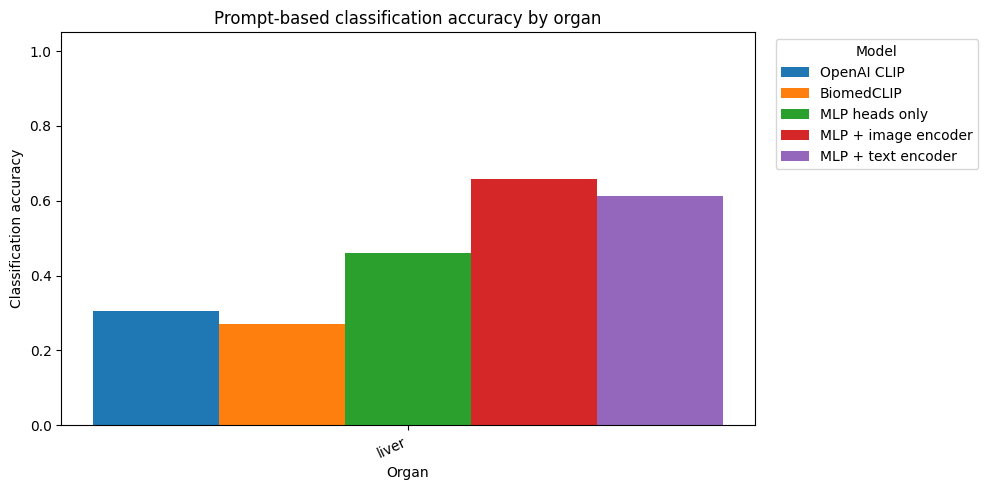

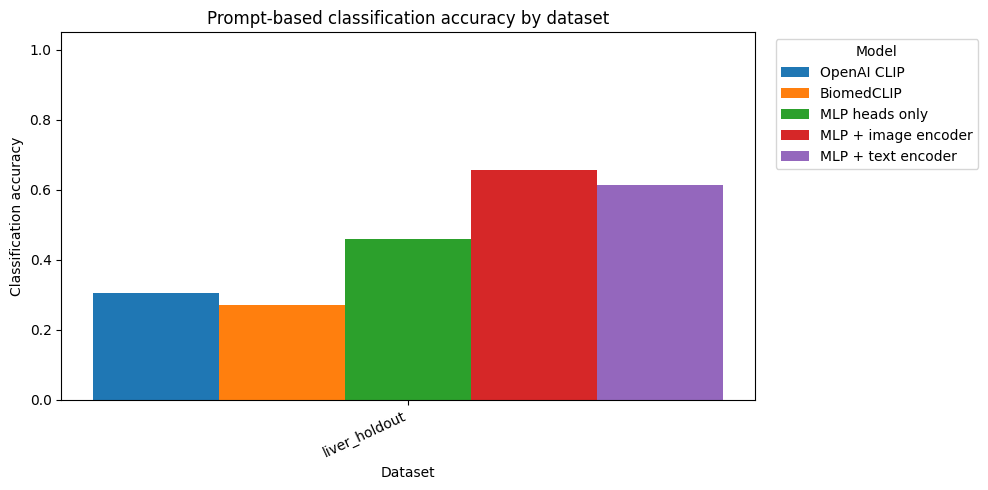

In [ ]:

# Grouped bar plots: models clustered within each organ / dataset

# Reuse existing color map if available; otherwise define a fallback.
# if "model_colors" not in globals():
model_colors = {
    "OpenAI CLIP": "#1f77b4",
    "BiomedCLIP": "#ff7f0e",
    "MLP head only": "#2ca02c",
    "MLP + image encoder": "#d62728",
    "MLP + text encoder": "#9467bd",
}

def plot_grouped_accuracy_bars(results_df, title, xlabel):
    if len(results_df) == 0:
        print(f"No results available for: {title}")
        return

    models = list(results_df["model"].drop_duplicates())
    groups = list(results_df["group_name"].drop_duplicates())

    # preserve a sensible group ordering using sample count, then name
    group_order_df = (
        results_df[["group_name", "n_samples"]]
        .drop_duplicates()
        .sort_values(["group_name"])
    )
    groups = group_order_df["group_name"].tolist()

    width = 0.8 / max(len(models), 1)
    x = np.arange(len(groups))

    fig_width = max(10, 1.4 * len(groups) + 4)
    fig, ax = plt.subplots(figsize=(fig_width, 5))

    for i, model_name in enumerate(models):
        sub = results_df[results_df["model"] == model_name].copy()
        sub = sub.set_index("group_name").reindex(groups)
        heights = sub["accuracy"].to_numpy(dtype=float)

        ax.bar(
            x + (i - (len(models) - 1) / 2) * width,
            heights,
            width=width,
            label=model_name,
            color=model_colors.get(model_name, "#2ca02c"),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=25, ha="right")
    ax.set_ylabel("Classification accuracy")
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_grouped_accuracy_bars(
    per_organ_classification_results,
    title="Prompt-based classification accuracy by organ",
    xlabel="Organ",
)

plot_grouped_accuracy_bars(
    per_dataset_classification_results,
    title="Prompt-based classification accuracy by dataset",
    xlabel="Dataset",
)


### Save all outputs from the organized notebook

In [ ]:
import shutil
from pathlib import Path

# ============================================================
# Save all outputs to Drive (replaces peer's cell that wrote to /kaggle/working)
# ============================================================
final_results_dir = Path("/content/gdrive/MyDrive/liver_zeroshot_results/final_eval_outputs")
final_results_dir.mkdir(parents=True, exist_ok=True)

# Helper to safely save dataframes that may or may not exist
def safe_save(name, df_var):
    if df_var is None:
        print(f"  [skip] {name} not defined")
        return
    out = final_results_dir / f"{name}.csv"
    df_var.to_csv(out, index=False)
    print(f"  [saved] {name}.csv  ({out.stat().st_size / 1024:.1f} KB)")

print(f"Saving to: {final_results_dir}\n")

# Core outputs
safe_save("alignment_results",            globals().get("alignment_results"))
safe_save("zeroshot_summary",             globals().get("zs_summary_df"))
safe_save("linear_probe_per_organ",       globals().get("linear_probe_per_organ"))
safe_save("linear_probe_aggregate",       globals().get("linear_probe_aggregate"))
safe_save("fewshot_per_organ_raw",        globals().get("fewshot_per_organ_raw"))
safe_save("fewshot_per_organ_summary",    globals().get("fewshot_per_organ_summary"))
safe_save("fewshot_aggregate_raw",        globals().get("fewshot_aggregate_raw"))
safe_save("fewshot_aggregate_summary",    globals().get("fewshot_aggregate_summary"))
safe_save("retrieval_results",            globals().get("retrieval_results"))
safe_save("per_organ_classification",     globals().get("per_organ_classification_results"))
safe_save("per_dataset_classification",   globals().get("per_dataset_classification_results"))

# Optional diagnostics (only if user ran those cells)
safe_save("linear_probe_bootstrap_ci",    globals().get("linear_probe_ci"))
safe_save("best_model_by_organ",          globals().get("best_by_organ"))

print(f"\nDone. Final outputs in: {final_results_dir}")
print(f"\nAll files:")
for f in sorted(final_results_dir.iterdir()):
    if f.is_file():
        print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

# Optional: zip into a single download artifact
zip_base = "/content/liver_final_eval_outputs"
zip_path = shutil.make_archive(zip_base, "zip", final_results_dir)
final_zip = Path("/content/gdrive/MyDrive/liver_zeroshot_results/liver_final_eval_outputs.zip")
shutil.copy(zip_path, final_zip)
print(f"\nZip archive: {final_zip}  ({final_zip.stat().st_size / 1024:.1f} KB)")

Saving to: /content/gdrive/MyDrive/liver_zeroshot_results/final_eval_outputs

  [saved] alignment_results.csv  (0.3 KB)
  [saved] zeroshot_summary.csv  (0.7 KB)
  [saved] linear_probe_per_organ.csv  (0.8 KB)
  [saved] linear_probe_aggregate.csv  (1.0 KB)
  [saved] fewshot_per_organ_raw.csv  (10.7 KB)
  [saved] fewshot_per_organ_summary.csv  (2.7 KB)
  [saved] fewshot_aggregate_raw.csv  (16.7 KB)
  [saved] fewshot_aggregate_summary.csv  (5.2 KB)
  [saved] retrieval_results.csv  (0.8 KB)
  [saved] per_organ_classification.csv  (0.5 KB)
  [saved] per_dataset_classification.csv  (0.5 KB)
  [saved] linear_probe_bootstrap_ci.csv  (1.5 KB)
  [saved] best_model_by_organ.csv  (0.1 KB)

Done. Final outputs in: /content/gdrive/MyDrive/liver_zeroshot_results/final_eval_outputs

All files:
  alignment_results.csv  (0.3 KB)
  best_model_by_organ.csv  (0.1 KB)
  fewshot_aggregate_raw.csv  (16.7 KB)
  fewshot_aggregate_summary.csv  (5.2 KB)
  fewshot_per_organ_raw.csv  (10.7 KB)
  fewshot_per_organ_su

In [ ]:
# Save all outputs from this notebook in one place

final_results_dir = Path("/kaggle/working/final_eval_outputs")
final_results_dir.mkdir(parents=True, exist_ok=True)

# Core outputs
alignment_results.to_csv(final_results_dir / "alignment_results.csv", index=False)
classification_results.to_csv(final_results_dir / "classification_results.csv", index=False)
linear_probe_per_organ.to_csv(final_results_dir / "linear_probe_per_organ.csv", index=False)
linear_probe_aggregate.to_csv(final_results_dir / "linear_probe_aggregate.csv", index=False)
fewshot_per_organ_raw.to_csv(final_results_dir / "fewshot_per_organ_raw.csv", index=False)
fewshot_per_organ_summary.to_csv(final_results_dir / "fewshot_per_organ_summary.csv", index=False)
fewshot_aggregate_raw.to_csv(final_results_dir / "fewshot_aggregate_raw.csv", index=False)
fewshot_aggregate_summary.to_csv(final_results_dir / "fewshot_aggregate_summary.csv", index=False)

# Additional diagnostics
if "retrieval_results" in globals():
    retrieval_results.to_csv(final_results_dir / "retrieval_results.csv", index=False)
if "linear_probe_ci" in globals():
    linear_probe_ci.to_csv(final_results_dir / "linear_probe_bootstrap_ci.csv", index=False)
if "best_by_organ" in globals():
    best_by_organ.to_csv(final_results_dir / "best_model_by_organ.csv", index=False)

print("Saved outputs to:", final_results_dir)

# Save the new per-group classification tables

results_dir = Path("/kaggle/working/final_eval_outputs/per_organ")
results_dir.mkdir(parents=True, exist_ok=True)

organ_label_space.to_csv(results_dir / "organ_label_space.csv", index=False)
dataset_label_space.to_csv(results_dir / "dataset_label_space.csv", index=False)
per_organ_classification_results.to_csv(results_dir / "per_organ_classification_results.csv", index=False)
per_dataset_classification_results.to_csv(results_dir / "per_dataset_classification_results.csv", index=False)

print("Saved:")
print(" ", results_dir / "organ_label_space.csv")
print(" ", results_dir / "dataset_label_space.csv")
print(" ", results_dir / "per_organ_classification_results.csv")
print(" ", results_dir / "per_dataset_classification_results.csv")

import shutil
from IPython.display import FileLink

zip_path = shutil.make_archive("/kaggle/working/final_eval_outputs", "zip", final_results_dir)
print("Created zip:", zip_path)
FileLink(zip_path)

In [ ]:
import copy
import gc
from collections import defaultdict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

config.update({
    # 8 points on the AUROC curve; adjust if runtime is too long
    "fewshot_e2e_fracs": [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30],
    "fewshot_e2e_num_seeds": 3,

    # conservative defaults
    "fewshot_e2e_epochs": 8,
    "fewshot_e2e_batch_size": 16,
    "fewshot_e2e_weight_decay": 1e-4,
    "fewshot_e2e_grad_clip": 1.0,

    # per-model-type LR
    "fewshot_e2e_lr": {
        "trained": 1e-5,
        "openai": 5e-6,
        "biomedclip": 5e-6,
    },
})

# If OpenAI CLIP crashes on CUDA in Kaggle, force it to CPU here.
fewshot_device_map = {
    # "OpenAI CLIP": torch.device("cpu") if "OpenAI CLIP" in model_registry else device,
    "OpenAI CLIP": device,
    "BiomedCLIP": device,
}
for model_name in trained_models:
    fewshot_device_map[model_name] = device

ORGAN_DISPLAY = {
    "breast": "breast",
    "lung": "lung",
    "liver": "liver",
    "thyroid": "thyroid",
    "carotid": "carotid artery",
}

def build_label_prompt_for_organ(label, organ):
    organ_text = ORGAN_DISPLAY.get(str(organ).strip().lower(), str(organ).strip().lower())
    label = str(label).strip().lower()
    return f"An ultrasound image of {organ_text} with {label} findings."

# Change config for fast training
config["fewshot_e2e_fracs"] = [0.01, 0.05, 0.10]
config["fewshot_e2e_num_seeds"] = 1
config["fewshot_e2e_epochs"] = 4

In [ ]:
trained_img_transform = transforms.Compose([
    transforms.Resize(config["image_size"]),
    transforms.CenterCrop(config["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize(mean=config["img_mean"], std=config["img_std"]),
])

def load_pil_images(paths):
    return [Image.open(p).convert("RGB") for p in paths]

def sample_fewshot_per_class(df, frac, seed, label_col="label"):
    pieces = []
    for label, group in df.groupby(label_col):
        n = int(np.ceil(len(group) * frac))
        if len(group) >= 2:
            n = max(2, n)
        else:
            n = 1
        n = min(len(group), n)
        pieces.append(group.sample(n=n, random_state=seed))
    out = pd.concat(pieces, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def multiclass_metrics(y_true, y_pred, y_prob, class_names):
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        if len(class_names) == 2:
            pos_class = class_names[1]
            y_true_bin = (np.asarray(y_true) == pos_class).astype(int)
            pos_idx = list(class_names).index(pos_class)
            out["auroc"] = roc_auc_score(y_true_bin, y_prob[:, pos_idx])
        else:
            y_bin = label_binarize(y_true, classes=class_names)
            out["auroc"] = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        out["auroc"] = np.nan

    return out

def summarize_across_organs(per_organ_df):
    if per_organ_df.empty:
        return pd.DataFrame(columns=["average_type", "auroc", "accuracy", "f1_weighted", "n_organs"])

    rows = []
    weights = per_organ_df["n_eval"].to_numpy()

    for avg_name in ["macro", "weighted_by_test_n"]:
        row = {"average_type": avg_name, "n_organs": int(len(per_organ_df))}
        for metric in ["auroc", "accuracy", "f1_weighted"]:
            vals = per_organ_df[metric].to_numpy(dtype=float)
            mask = ~np.isnan(vals)
            if mask.sum() == 0:
                row[metric] = np.nan
            elif avg_name == "macro":
                row[metric] = float(vals[mask].mean())
            else:
                row[metric] = float(np.average(vals[mask], weights=weights[mask]))
        rows.append(row)

    return pd.DataFrame(rows)

def iterate_minibatches(df, batch_size, seed):
    idx = np.arange(len(df))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    for start in range(0, len(idx), batch_size):
        yield df.iloc[idx[start:start + batch_size]].reset_index(drop=True)

In [ ]:
def clone_model_for_fewshot(model_name, spec, target_device):
    model = copy.deepcopy(spec["model"])
    model = model.to(target_device)
    model.train()
    return model

def get_trainable_scale(kind, model):
    if kind == "trained":
        # training code used sim / temperature
        scale = 1.0 / model.log_temperature.exp()
    else:
        scale = model.logit_scale.exp()
    return torch.clamp(scale, max=100.0)

def encode_text_prompts(kind, model, prompt_texts, target_device):
    if kind == "trained":
        ids, mask = tokenize_texts(
            list(prompt_texts),
            tokenizer,
            max_length=config["max_seq_len"],
            device=target_device,
        )
        text_embs = model.encode_text(ids, mask)
        return text_embs

    elif kind == "openai":
        text_inputs = openai_clip_processor(
            text=list(prompt_texts),
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to(target_device)

        text_outputs = model.text_model(
            input_ids=text_inputs["input_ids"],
            attention_mask=text_inputs["attention_mask"],
        )
        text_embs = model.text_projection(text_outputs.pooler_output)
        text_embs = F.normalize(text_embs, dim=-1)
        return text_embs

    elif kind == "biomedclip":
        text_tokens = biomedclip_tokenizer(list(prompt_texts), context_length=256).to(target_device)
        text_embs = model.encode_text(text_tokens)
        text_embs = F.normalize(text_embs, dim=-1)
        return text_embs

    else:
        raise ValueError(f"Unknown kind: {kind}")

def encode_image_batch(kind, model, image_paths, target_device):
    pil_images = load_pil_images(image_paths)

    if kind == "trained":
        images = torch.stack([trained_img_transform(img) for img in pil_images]).to(target_device)
        img_embs = model.encode_image(images)
        return img_embs

    elif kind == "openai":
        img_inputs = openai_clip_processor(
            images=pil_images,
            return_tensors="pt",
        ).to(target_device)

        vision_outputs = model.vision_model(pixel_values=img_inputs["pixel_values"])
        img_embs = model.visual_projection(vision_outputs.pooler_output)
        img_embs = F.normalize(img_embs, dim=-1)
        return img_embs

    elif kind == "biomedclip":
        images = torch.stack([biomedclip_preprocess(img) for img in pil_images]).to(target_device)
        img_embs = model.encode_image(images)
        img_embs = F.normalize(img_embs, dim=-1)
        return img_embs

    else:
        raise ValueError(f"Unknown kind: {kind}")

In [ ]:
def evaluate_prompt_classifier(kind, model, df, class_names, organ, target_device, batch_size=32):
    model.eval()

    prompt_texts = [build_label_prompt_for_organ(c, organ) for c in class_names]
    with torch.no_grad():
        text_embs = encode_text_prompts(kind, model, prompt_texts, target_device)
        scale = get_trainable_scale(kind, model)

    y_true, y_pred = [], []
    all_probs = []

    for start in range(0, len(df), batch_size):
        batch_df = df.iloc[start:start + batch_size].reset_index(drop=True)
        image_paths = batch_df["image_path"].tolist()

        with torch.no_grad():
            img_embs = encode_image_batch(kind, model, image_paths, target_device)
            logits = scale * (img_embs @ text_embs.T)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

        pred_idx = probs.argmax(axis=1)
        pred_labels = [class_names[i] for i in pred_idx]

        y_true.extend(batch_df["label"].astype(str).str.lower().tolist())
        y_pred.extend(pred_labels)
        all_probs.append(probs)

    y_prob = np.concatenate(all_probs, axis=0)
    metrics = multiclass_metrics(y_true, y_pred, y_prob, class_names)
    metrics["n_eval"] = int(len(y_true))
    return metrics, y_true, y_pred, y_prob

def train_prompt_classifier_for_one_organ(model_name, spec, support_df, val_df, organ, class_names, seed, target_device):
    kind = spec["kind"]

    model = clone_model_for_fewshot(model_name, spec, target_device)
    lr = config["fewshot_e2e_lr"][kind]

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=config["fewshot_e2e_weight_decay"],
    )

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf
    history = []

    for epoch in range(config["fewshot_e2e_epochs"]):
        model.train()
        epoch_losses = []

        for batch_df in iterate_minibatches(support_df, config["fewshot_e2e_batch_size"], seed + epoch):
            image_paths = batch_df["image_path"].tolist()
            labels = batch_df["label"].astype(str).str.lower().tolist()

            label_to_idx = {c: i for i, c in enumerate(class_names)}
            targets = torch.tensor([label_to_idx[y] for y in labels], dtype=torch.long, device=target_device)

            prompt_texts = [build_label_prompt_for_organ(c, organ) for c in class_names]

            img_embs = encode_image_batch(kind, model, image_paths, target_device)
            text_embs = encode_text_prompts(kind, model, prompt_texts, target_device)
            scale = get_trainable_scale(kind, model)

            logits = scale * (img_embs @ text_embs.T)
            loss = F.cross_entropy(logits, targets)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config["fewshot_e2e_grad_clip"])
            optimizer.step()

            epoch_losses.append(loss.item())

        # validation selection
        val_metrics, _, _, _ = evaluate_prompt_classifier(
            kind=kind,
            model=model,
            df=val_df,
            class_names=class_names,
            organ=organ,
            target_device=target_device,
            batch_size=config["fewshot_e2e_batch_size"],
        )

        mean_loss = float(np.mean(epoch_losses)) if epoch_losses else np.nan
        history.append({
            "epoch": epoch + 1,
            "train_loss": mean_loss,
            "val_auroc": val_metrics["auroc"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1_weighted": val_metrics["f1_weighted"],
        })

        if val_metrics["f1_weighted"] > best_val_f1:
            best_val_f1 = val_metrics["f1_weighted"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    model.eval()
    return model, pd.DataFrame(history), best_val_f1

def run_e2e_fewshot_for_one_organ(model_name, spec, train_meta, val_meta, test_meta, organ, frac, seed, target_device):
    tr = train_meta[train_meta["organ"] == organ].copy()
    va = val_meta[val_meta["organ"] == organ].copy()
    te = test_meta[test_meta["organ"] == organ].copy()

    train_counts = tr["label"].value_counts()
    keep_classes = train_counts[train_counts >= 2].index.tolist()

    tr = tr[tr["label"].isin(keep_classes)].copy()
    va = va[va["label"].isin(keep_classes)].copy()
    te = te[te["label"].isin(keep_classes)].copy()

    if tr["label"].nunique() < 2 or len(te) == 0:
        return None, None

    support_df = sample_fewshot_per_class(tr, frac=frac, seed=seed, label_col="label")
    class_names = sorted(support_df["label"].astype(str).str.lower().unique().tolist())

    va = va[va["label"].isin(class_names)].copy()
    te = te[te["label"].isin(class_names)].copy()

    if len(va) == 0 or len(te) == 0 or len(class_names) < 2:
        return None, None

    adapted_model, train_hist_df, best_val_f1 = train_prompt_classifier_for_one_organ(
        model_name=model_name,
        spec=spec,
        support_df=support_df,
        val_df=va,
        organ=organ,
        class_names=class_names,
        seed=seed,
        target_device=target_device,
    )

    test_metrics, y_true, y_pred, y_prob = evaluate_prompt_classifier(
        kind=spec["kind"],
        model=adapted_model,
        df=te,
        class_names=class_names,
        organ=organ,
        target_device=fewshot_device_map[model_name],
        batch_size=config["fewshot_e2e_batch_size"],
    )

    row = {
        "model": model_name,
        "setting": "fewshot_e2e_full_clip",
        "fewshot_frac": frac,
        "seed": seed,
        "organ": organ,
        "n_train_support": int(len(support_df)),
        "n_val": int(len(va)),
        "n_test": int(len(te)),
        "n_classes": int(len(class_names)),
        "best_val_f1_weighted": float(best_val_f1),
        **test_metrics,
    }

    # free memory aggressively
    del adapted_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row, train_hist_df

In [ ]:
import gc
import torch

del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
e2e_fewshot_rows = []
e2e_fewshot_histories = []

train_meta = labeled_train_df.copy().reset_index(drop=True)
val_meta   = labeled_val_df.copy().reset_index(drop=True)
test_meta  = labeled_test_df.copy().reset_index(drop=True)

organs = sorted(set(train_meta["organ"]) & set(val_meta["organ"]) & set(test_meta["organ"]))

for model_name, spec in model_registry.items():
    print(f"\n=== End-to-end few-shot adaptation: {model_name} ===")
    print("device:", fewshot_device_map[model_name])

    for frac in config["fewshot_e2e_fracs"]:
        print(f"  fraction = {frac:.3f}")

        for rep in range(config["fewshot_e2e_num_seeds"]):
            seed = config["random_seed"] + rep

            for organ in organs:
                print(f"    seed={seed} organ={organ}")

                row, hist_df = run_e2e_fewshot_for_one_organ(
                    model_name=model_name,
                    spec=spec,
                    train_meta=train_meta,
                    val_meta=val_meta,
                    test_meta=test_meta,
                    organ=organ,
                    frac=frac,
                    seed=seed,
                    target_device="cuda",
                )

                if row is not None:
                    e2e_fewshot_rows.append(row)
                    hist_df["model"] = model_name
                    hist_df["fewshot_frac"] = frac
                    hist_df["seed"] = seed
                    hist_df["organ"] = organ
                    e2e_fewshot_histories.append(hist_df)

e2e_fewshot_per_organ_raw = pd.DataFrame(e2e_fewshot_rows)
e2e_fewshot_training_history = (
    pd.concat(e2e_fewshot_histories, ignore_index=True)
    if len(e2e_fewshot_histories) > 0
    else pd.DataFrame()
)

print("Done.")
print("rows:", len(e2e_fewshot_per_organ_raw))
e2e_fewshot_per_organ_raw.head()


=== End-to-end few-shot adaptation: OpenAI CLIP ===
device: cuda
  fraction = 0.010
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver
  fraction = 0.050
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver
  fraction = 0.100
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver

=== End-to-end few-shot adaptation: BiomedCLIP ===
device: cuda
  fraction = 0.010
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver
  fraction = 0.050
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver
  fraction = 0.100
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver

=== End-to-end few-shot adaptation: MLP heads only ===
device: cuda
  fraction = 0.010
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver
  fraction = 0.050
    seed=42 organ=liver
    seed=43 organ=liver
    seed=44 organ=liver
  fraction = 0.100
    seed=42 organ=liver
    seed=43 organ=liver
    s

,model,setting,fewshot_frac,seed,organ,n_train_support,n_val,n_test,n_classes,best_val_f1_weighted,accuracy,f1_weighted,auroc,n_eval
0,OpenAI CLIP,fewshot_e2e_full_clip,0.01,42,liver,8,111,111,3,0.596914,0.657658,0.610414,0.781629,111
1,OpenAI CLIP,fewshot_e2e_full_clip,0.01,43,liver,8,111,111,3,0.685737,0.648649,0.647248,0.810280,111
2,OpenAI CLIP,fewshot_e2e_full_clip,0.01,44,liver,8,111,111,3,0.501851,0.585586,0.483515,0.530361,111
3,OpenAI CLIP,fewshot_e2e_full_clip,0.05,42,liver,27,111,111,3,0.632663,0.666667,0.648664,0.816764,111
4,OpenAI CLIP,fewshot_e2e_full_clip,0.05,43,liver,27,111,111,3,0.672423,0.657658,0.674417,0.807952,111


In [ ]:
e2e_fewshot_aggregate_rows = []

for (model_name, frac, seed), df_seed in e2e_fewshot_per_organ_raw.groupby(["model", "fewshot_frac", "seed"]):
    agg = summarize_across_organs(df_seed)
    agg["model"] = model_name
    agg["setting"] = "fewshot_e2e_full_clip"
    agg["fewshot_frac"] = frac
    agg["seed"] = seed
    e2e_fewshot_aggregate_rows.append(agg)

e2e_fewshot_aggregate_raw = pd.concat(e2e_fewshot_aggregate_rows, ignore_index=True)

e2e_fewshot_aggregate_summary = (
    e2e_fewshot_aggregate_raw
    .groupby(["model", "setting", "fewshot_frac", "average_type"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_organs_mean=("n_organs", "mean"),
    )
)

e2e_fewshot_per_organ_summary = (
    e2e_fewshot_per_organ_raw
    .groupby(["model", "setting", "fewshot_frac", "organ"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_std=("auroc", "std"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        f1_weighted_mean=("f1_weighted", "mean"),
        f1_weighted_std=("f1_weighted", "std"),
        n_test_mean=("n_test", "mean"),
    )
)

display(
    e2e_fewshot_aggregate_summary.sort_values(
        ["average_type", "fewshot_frac", "auroc_mean"],
        ascending=[True, True, False]
    )
)

,model,setting,fewshot_frac,average_type,auroc_mean,auroc_std,accuracy_mean,accuracy_std,f1_weighted_mean,f1_weighted_std,n_organs_mean
6,MLP + image encoder,fewshot_e2e_full_clip,0.01,macro,0.907058,0.011701,0.762763,0.020805,0.727907,0.043607,1.0
12,MLP + text encoder,fewshot_e2e_full_clip,0.01,macro,0.726911,0.059977,0.621622,0.039269,0.490329,0.065154,1.0
24,OpenAI CLIP,fewshot_e2e_full_clip,0.01,macro,0.707423,0.154008,0.630631,0.039269,0.580392,0.085896,1.0
0,BiomedCLIP,fewshot_e2e_full_clip,0.01,macro,0.661020,0.041524,0.549550,0.041284,0.514312,0.028773,1.0
18,MLP heads only,fewshot_e2e_full_clip,0.01,macro,0.501725,0.077068,0.591592,0.005201,0.454795,0.019691,1.0
8,MLP + image encoder,fewshot_e2e_full_clip,0.05,macro,0.869688,0.067070,0.726727,0.042575,0.687751,0.085203,1.0
26,OpenAI CLIP,fewshot_e2e_full_clip,0.05,macro,0.797677,0.025807,0.657658,0.009009,0.655949,0.016111,1.0
2,BiomedCLIP,fewshot_e2e_full_clip,0.05,macro,0.718901,0.033375,0.573574,0.036409,0.554580,0.022800,1.0
14,MLP + text encoder,fewshot_e2e_full_clip,0.05,macro,0.613496,0.086310,0.612613,0.023836,0.487915,0.060600,1.0
20,MLP heads only,fewshot_e2e_full_clip,0.05,macro,0.512285,0.055588,0.594595,0.000000,0.443426,0.000000,1.0


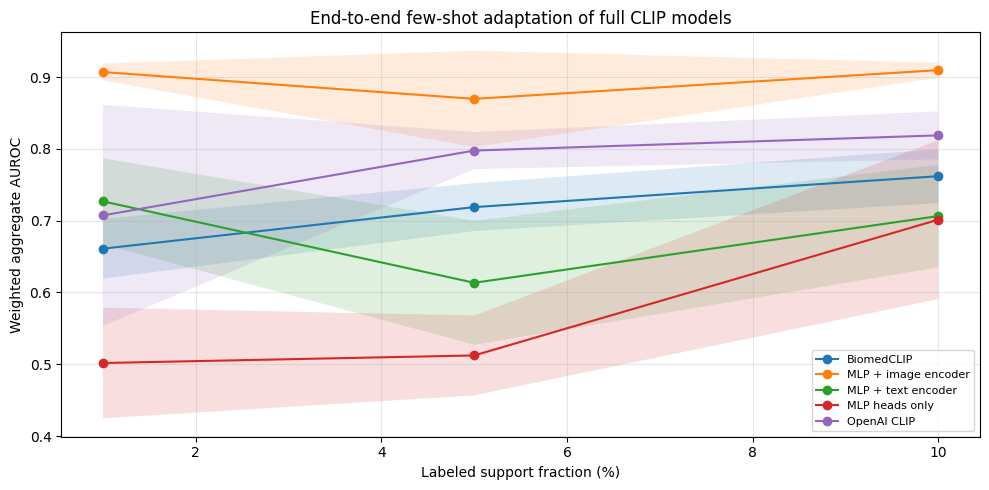

In [ ]:
# AUROC curve with more points
plot_df = e2e_fewshot_aggregate_summary[
    e2e_fewshot_aggregate_summary["average_type"] == "weighted_by_test_n"
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for model_name in plot_df["model"].unique():
    sub = plot_df[plot_df["model"] == model_name].sort_values("fewshot_frac")
    x = sub["fewshot_frac"].to_numpy() * 100
    y = sub["auroc_mean"].to_numpy()
    yerr = sub["auroc_std"].fillna(0).to_numpy()

    ax.plot(x, y, marker="o", label=model_name)
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.15)

ax.set_xlabel("Labeled support fraction (%)")
ax.set_ylabel("Weighted aggregate AUROC")
ax.set_title("End-to-end few-shot adaptation of full CLIP models")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
config["fewshot_e2e_num_seeds"] = 3
print("Updated:", config["fewshot_e2e_num_seeds"])

Updated: 3


In [ ]:
import shutil
from pathlib import Path

# ============================================================
# Save end-to-end few-shot outputs to Drive
# ============================================================
e2e_results_dir = Path("/content/gdrive/MyDrive/liver_zeroshot_results/final_eval_outputs/e2e_fewshot_eval")
e2e_results_dir.mkdir(parents=True, exist_ok=True)

# Helper for safe save
def safe_save(name, df_var):
    if df_var is None:
        print(f"  [skip] {name} not defined")
        return
    if hasattr(df_var, '__len__') and len(df_var) == 0:
        print(f"  [skip] {name} is empty")
        return
    out = e2e_results_dir / f"{name}.csv"
    df_var.to_csv(out, index=False)
    print(f"  [saved] {name}.csv  ({out.stat().st_size / 1024:.1f} KB)")

print(f"Saving to: {e2e_results_dir}\n")

safe_save("e2e_fewshot_per_organ_raw",      globals().get("e2e_fewshot_per_organ_raw"))
safe_save("e2e_fewshot_per_organ_summary",  globals().get("e2e_fewshot_per_organ_summary"))
safe_save("e2e_fewshot_aggregate_raw",      globals().get("e2e_fewshot_aggregate_raw"))
safe_save("e2e_fewshot_aggregate_summary",  globals().get("e2e_fewshot_aggregate_summary"))
safe_save("e2e_fewshot_training_history",   globals().get("e2e_fewshot_training_history"))

print(f"\nDone. Files in: {e2e_results_dir}")
print(f"\nAll files:")
for f in sorted(e2e_results_dir.iterdir()):
    if f.is_file():
        print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

# Zip the FULL final_eval_outputs folder (linear probe + few-shot + e2e)
final_results_dir = Path("/content/gdrive/MyDrive/liver_zeroshot_results/final_eval_outputs")
zip_base = "/content/liver_full_final_eval_outputs"
zip_path = shutil.make_archive(zip_base, "zip", final_results_dir)
final_zip = Path("/content/gdrive/MyDrive/liver_zeroshot_results/liver_full_final_eval_outputs.zip")
shutil.copy(zip_path, final_zip)
print(f"\nFull zip archive (with linear probe + few-shot + e2e):")
print(f"  {final_zip}  ({final_zip.stat().st_size / 1024:.1f} KB)")

Saving to: /content/gdrive/MyDrive/liver_zeroshot_results/final_eval_outputs/e2e_fewshot_eval

  [saved] e2e_fewshot_per_organ_raw.csv  (6.5 KB)
  [saved] e2e_fewshot_per_organ_summary.csv  (2.6 KB)
  [saved] e2e_fewshot_aggregate_raw.csv  (10.3 KB)
  [saved] e2e_fewshot_aggregate_summary.csv  (5.2 KB)
  [saved] e2e_fewshot_training_history.csv  (18.9 KB)

Done. Files in: /content/gdrive/MyDrive/liver_zeroshot_results/final_eval_outputs/e2e_fewshot_eval

All files:
  e2e_fewshot_aggregate_raw.csv  (10.3 KB)
  e2e_fewshot_aggregate_summary.csv  (5.2 KB)
  e2e_fewshot_per_organ_raw.csv  (6.5 KB)
  e2e_fewshot_per_organ_summary.csv  (2.6 KB)
  e2e_fewshot_training_history.csv  (18.9 KB)

Full zip archive (with linear probe + few-shot + e2e):
  /content/gdrive/MyDrive/liver_zeroshot_results/liver_full_final_eval_outputs.zip  (23.4 KB)
